# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

## Importing necessary libraries and data

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [103]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)


In [104]:
# IMPORTING dataset

hotel = pd.read_csv("INNHotelsGroup.csv")
data = hotel.copy()  # save the original


# Data Overview

- Observations
- Sanity checks

### View the first and last 5 rows of the dataset

In [105]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00000,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68000,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00000,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00000,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50000,0,Canceled


In [106]:
data.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80000,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95000,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39000,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50000,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67000,0,Not_Canceled


### Understand the shape of the dataset

In [107]:
# Understand the shape of the dataset

data.shape



(36275, 19)

**The dataset contains:**

36,275 hotel bookings

19 variables describing customer behavior, booking details, and cancellation status.

### Check Column Names

In [108]:
data.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

This helps us understand all available features.  Booking_ID is number but it is not important for future counting.


### Check the data types of the columns for the dataset

In [109]:
# Check the data types

print("\nInfo:")
data.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_

**Most columns** are **intejers or floats**. Booking ID, type_of_meal_plan, room_type_reserved, market_segment_type, booking_status  are **objects.**

In [110]:
# checking for duplicate values

print("\nNumber of duplicated rows:", data.duplicated().sum())



Number of duplicated rows: 0


### Let's drop the Booking_ID column first before we proceed forward.

In [111]:

data.drop('Booking_ID', axis=1, inplace=True, errors='ignore')

## Data Overview & Observations

The dataset contains 36,275 rows and 19 columns.

Target Variable

**The dependent variable** is booking_status, which indicates whether a booking was Canceled or Not_Canceled.
This makes the problem a binary classification.

**Feature Types**
The dataset includes a mix of numerical and categorical features:

Numerical features:

no_of_adults, no_of_children, no_of_weekend_nights,

no_of_week_nights, lead_time, arrival_year,

arrival_month, arrival_date, repeated_guest,

no_of_previous_cancellations,

no_of_previous_bookings_not_canceled,

avg_price_per_room, no_of_special_requests.

Categorical features:

type_of_meal_plan,

room_type_reserved,

market_segment_type,

booking_status,

 Booking_ID.

There are no missing values in any column.

The dataset contains 0 duplicated rows.

Initial Statistical Observations
Based on the descriptive statistics:

Variables like no_of_adults, no_of_children, and no_of_special_requests appear to have reasonable ranges with no immediately suspicious values.

The arrival date components (arrival_year, arrival_month, arrival_date) fall within expected calendar ranges.

## Sanity Checks

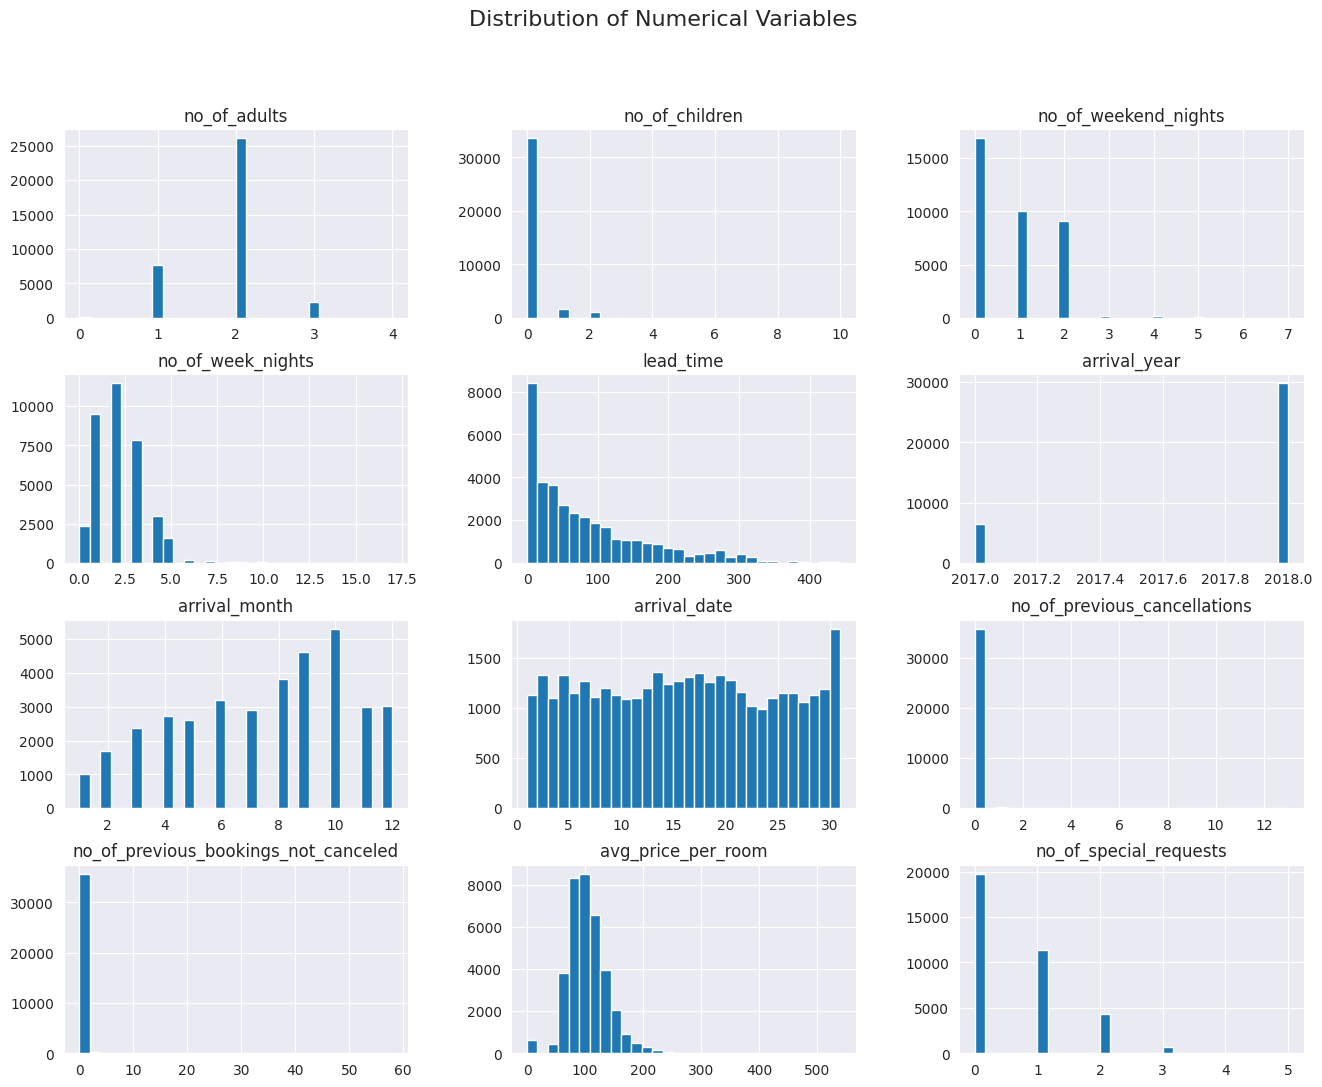

In [112]:
sns.set_style("darkgrid")

# check for numeric columns only
numeric_cols = [
    "no_of_adults",
    "no_of_children",
    "no_of_weekend_nights",
    "no_of_week_nights",
    "lead_time",
    "arrival_year",
    "arrival_month",
    "arrival_date",
    "no_of_previous_cancellations",
    "no_of_previous_bookings_not_canceled",
    "avg_price_per_room",
    "no_of_special_requests"
]

# making histogram to check unusial values
data[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.show()



There are no bookings with both 0 adults and 0 children.

No Negative Values

* arrival_year ranges from valid recent years (e.g., 2017–2018).

* arrival_month ranges from 1 to 12.

* arrival_date ranges from 1 to 31.

* avg_price_per_room contains no negative values. Some prices are 0, could be promotions.

Some high values may represent dynamic pricing.

Lead_time values are non‑negative and can be large, which is expected since some guests book far in advance.


## Statistical summary

In [113]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.00000,1.84496,0.51871,0.00000,2.00000,2.00000,2.00000,4.00000
no_of_children,36275.00000,0.10528,0.40265,0.00000,0.00000,0.00000,0.00000,10.00000
no_of_weekend_nights,36275.00000,0.81072,0.87064,0.00000,0.00000,1.00000,2.00000,7.00000
no_of_week_nights,36275.00000,2.20430,1.41090,0.00000,1.00000,2.00000,3.00000,17.00000
required_car_parking_space,36275.00000,0.03099,0.17328,0.00000,0.00000,0.00000,0.00000,1.00000
lead_time,36275.00000,85.23256,85.93082,0.00000,17.00000,57.00000,126.00000,443.00000
arrival_year,36275.00000,2017.82043,0.38384,2017.00000,2018.00000,2018.00000,2018.00000,2018.00000
arrival_month,36275.00000,7.42365,3.06989,1.00000,5.00000,8.00000,10.00000,12.00000
arrival_date,36275.00000,15.59700,8.74045,1.00000,8.00000,16.00000,23.00000,31.00000
repeated_guest,36275.00000,0.02564,0.15805,0.00000,0.00000,0.00000,0.00000,1.00000


1. **no_of_adults:** Most bookings are for 2 adults. 75% percentile = 2 - Majority of bookings include exactly 2 adults. Maximum number of adults in a booking is 4.

2. **no_of_children:** mean = 0.10 - Most bookings have no children. Max = 10 - A few large family bookings exist.

3. **no_of_weekend_nights:** Guests typically stay 0–1 weekend nights. Some long weekend stays exist.

4. **no_of_week_nights:** typical weekday stay is 2 nights. Max = 17 - Some long business stays.

5. **required_car_parking_space:** Only 3% of guests request parking. Most values = 0.

6. **lead_time:** guests book on average almost 3 months in advance. Some bookings are made more than a year ahead. This feature has a long right tail (important for cancellations).

7. **arrival_year:** Data covers 2017–2018. No anomalies.

8. **arrival_month:** many bookings occur in summer and authem.

9. **arrival_date:**valid dates.

10. **repeated_guest:** only 2.5% of guests are repeat customers. Most values = 0.

11. **no_of_previous_cancellations:** most guests never canceled before. Max = 13 - A few customers have many past cancellations.

12. **no_of_previous_bookings_not_canceled:** Most guests are first‑timers. 58 loyal customers exist.

13. avg_price_per_room: average room price is around €103. Some premium rooms or peak‑season pricing.

Min = 0 → Needs checking (could be promotions).

14. no_of_special_requests: most guests make 0–1 special requests.


## OUTLIER ANALYSIS



Boxplots help visualize the spread of numerical variables and identify potential outliers.

Outliers are unusually high or low values that may affect model performance or indicate special customer behavior.

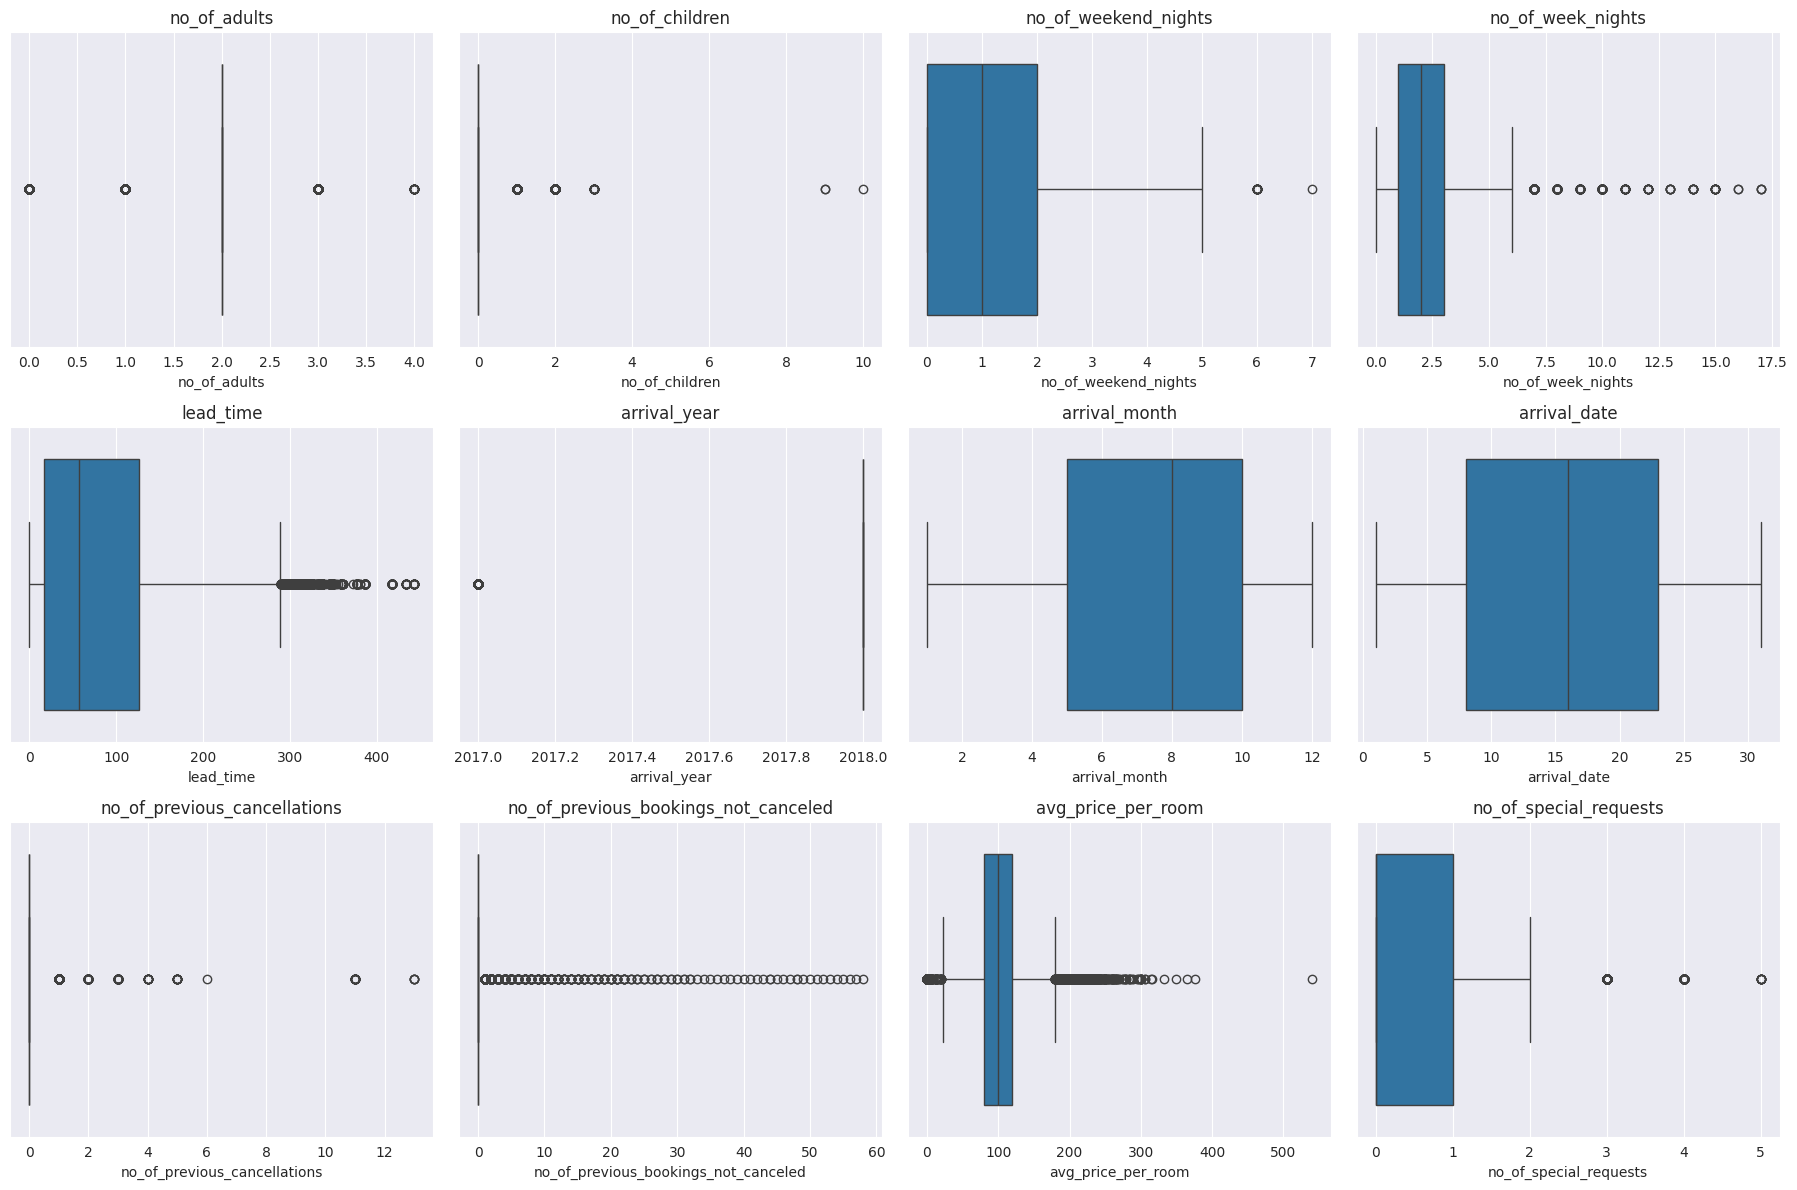

In [114]:
plt.figure(figsize=(18,12))

for i, col in enumerate(numeric_cols):

    plt.subplot(3,4,i+1)

    sns.boxplot(x=data[col])

    plt.title(col)

plt.tight_layout()

plt.show()

### Observations from Outlier Analysis

Several numerical variables contain outliers.

- lead_time has **extreme high values**, meaning some customers book** far in advance.**
- avg_price_per_room contains several **unusually high prices**, likely caused by premium rooms, holidays, or seasonal pricing.
- no_of_previous_cancellations contains a few customers with **repeated cancellation behavior.**

These outliers may contain useful business information rather than errors, so they will be retained for modeling.

### Target Variable Distribution

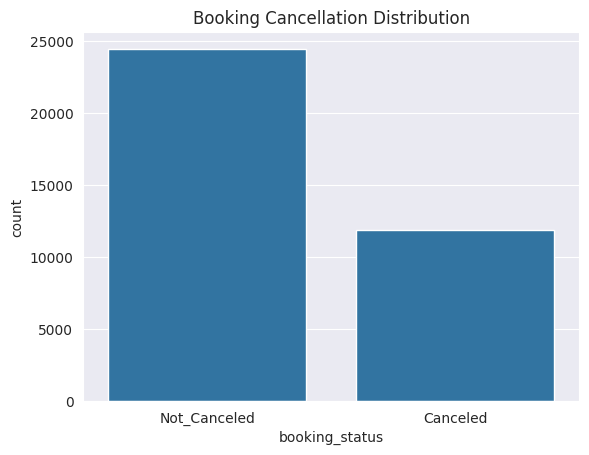

In [115]:
sns.countplot(data=data, x="booking_status")

plt.title("Booking Cancellation Distribution")

plt.show()

# Objective

The dataset contains both canceled and non-canceled bookings.

**A substantial proportion of reservations were canceled**, indicating that **cancellation prediction is an important business problem** for the hotel.

## Summary

Overall, the dataset is clean, complete, and logically consistent.
This makes the dataset ready for further preprocessing, exploratory data analysis, and model building.

# Exploratory Data Analysis (EDA)

EDA helps understand the dataset, identify patterns, detect outliers, and explore relationships between variables before model building.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. What are the busiest months in the hotel?
2. Which market segment do most of the guests come from?
3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?
4. What percentage of bookings are canceled?
5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?
6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

# 1. Univariate Analysis

Univariate analysis focuses on analyzing **individual variables** separately.

In [116]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### 1. lead_time

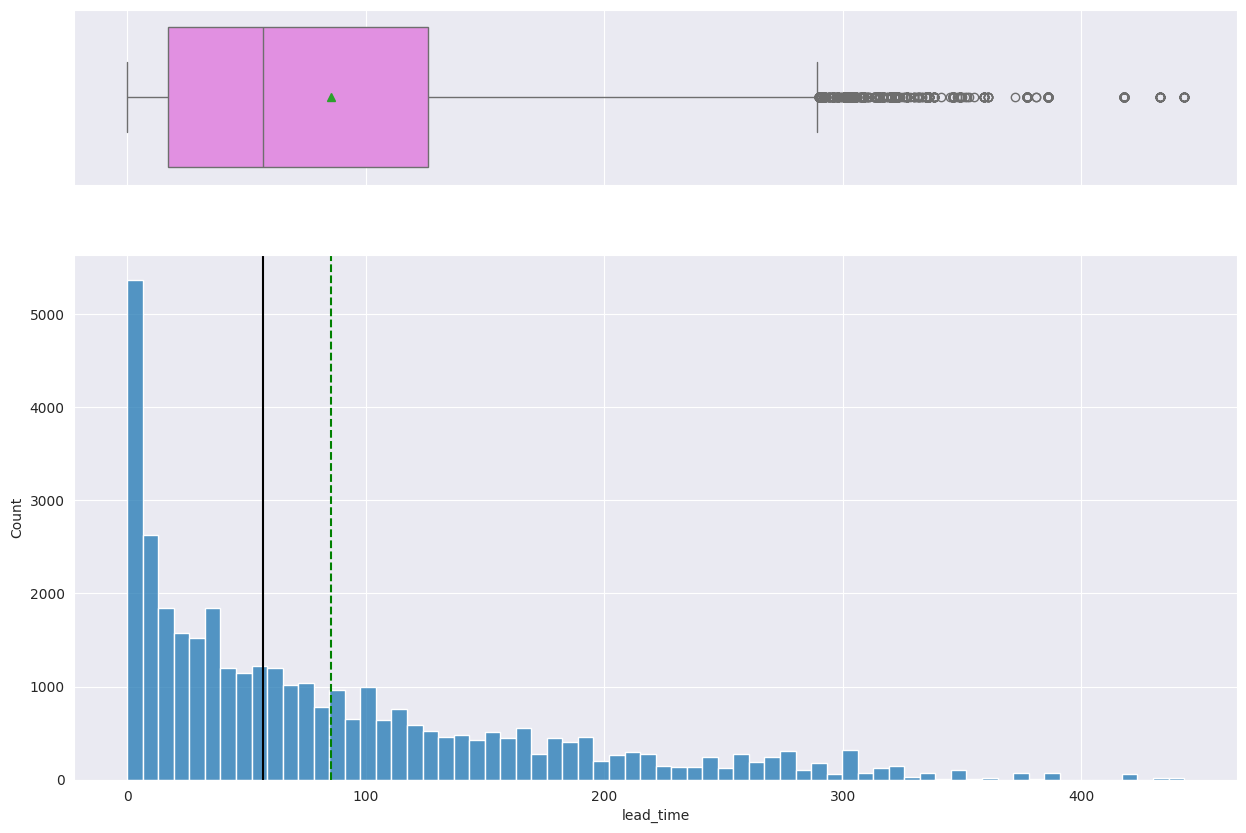

In [117]:
histogram_boxplot(data, "lead_time")



* Lead time is highly **right‑skewed.**

* Most customers book within **0–150 days.**

* A small group books **extremely early **(300–450 days).

These long lead times are not errors — they represent early planners.

### 2. avg_price_per_room

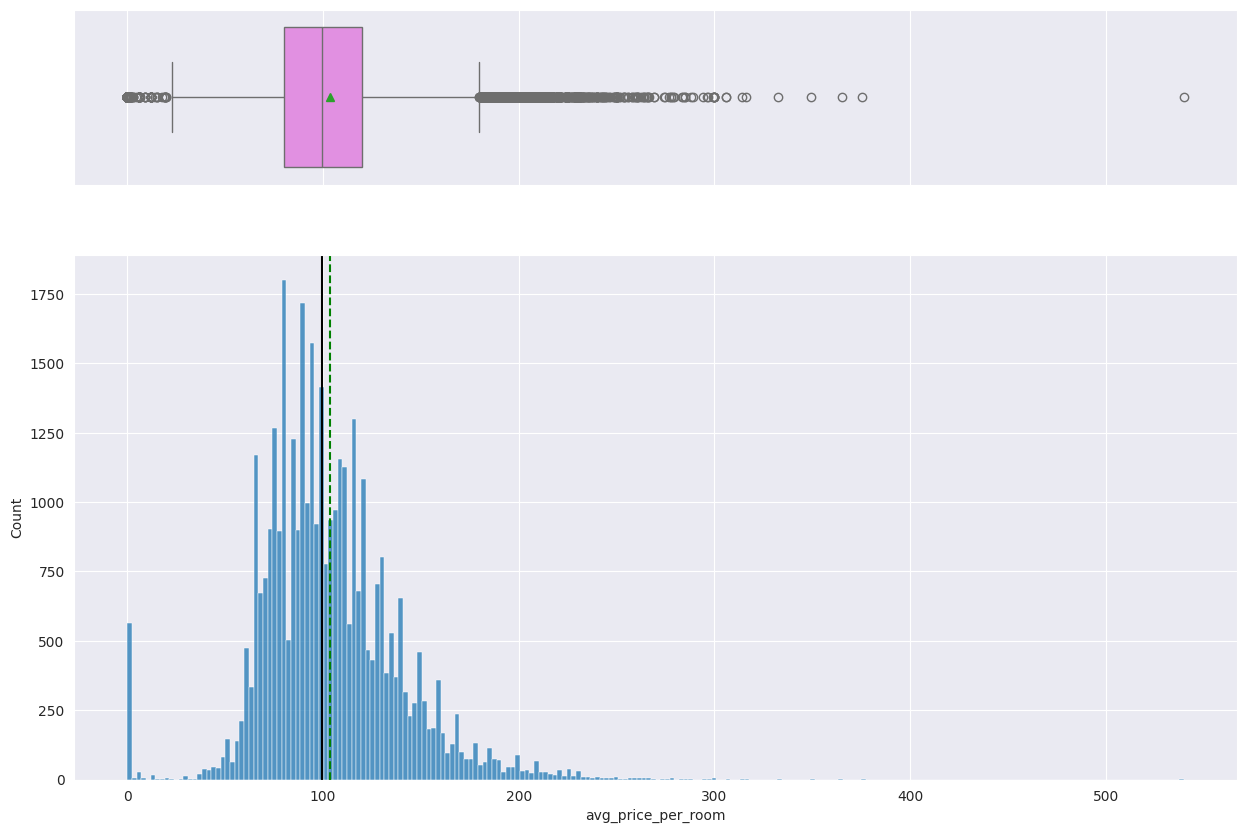

In [118]:
histogram_boxplot(data, "avg_price_per_room")


The distribution is**right‑skewed.**

Most rooms cost between **80–150 euros.**
Medium price is **~100 euros.**

A few rooms cost 300–540 euros — **premium or seasonal pricing.**



### Cheking the rooms with price = 0

In [119]:
data[data["avg_price_per_room"] == 0]

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
63,1,0,0,1,Meal Plan 1,0,Room_Type 1,2,2017,9,10,Complementary,0,0,0,0.00000,1,Not_Canceled
145,1,0,0,2,Meal Plan 1,0,Room_Type 1,13,2018,6,1,Complementary,1,3,5,0.00000,1,Not_Canceled
209,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,2018,2,27,Complementary,0,0,0,0.00000,1,Not_Canceled
266,1,0,0,2,Meal Plan 1,0,Room_Type 1,1,2017,8,12,Complementary,1,0,1,0.00000,1,Not_Canceled
267,1,0,2,1,Meal Plan 1,0,Room_Type 1,4,2017,8,23,Complementary,0,0,0,0.00000,1,Not_Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35983,1,0,0,1,Meal Plan 1,0,Room_Type 7,0,2018,6,7,Complementary,1,4,17,0.00000,1,Not_Canceled
36080,1,0,1,1,Meal Plan 1,0,Room_Type 7,0,2018,3,21,Complementary,1,3,15,0.00000,1,Not_Canceled
36114,1,0,0,1,Meal Plan 1,0,Room_Type 1,1,2018,3,2,Online,0,0,0,0.00000,0,Not_Canceled
36217,2,0,2,1,Meal Plan 1,0,Room_Type 2,3,2017,8,9,Online,0,0,0,0.00000,2,Not_Canceled


### rooms with price = 0 by the market_segment_type

In [120]:
data.loc[data["avg_price_per_room"] == 0, "market_segment_type"].value_counts()

,count
market_segment_type,
Complementary,354
Online,191


### Cupping the Upper_Whisker

In [121]:
# Calculating the 25th quantile
Q1 = data["avg_price_per_room"].quantile(0.25)

# Calculating the 75th quantile
Q3 = data["avg_price_per_room"].quantile(0.75)  ## Complete the code to calculate 75th quantile for average price per room

# Calculating IQR
IQR = Q3 - Q1

# Calculating value of upper whisker
Upper_Whisker = Q3 + 1.5 * IQR
Upper_Whisker

np.float64(179.55)

In [122]:
# assigning the outliers the value of upper whisker
data.loc[data["avg_price_per_room"] >= 500, "avg_price_per_room"] = Upper_Whisker

Prices above 500 euros are extreme outliers and may distort model training.

These outliers likely represent premium rooms, holiday pricing, or special events.

**Instead of deleting these rows, we cap them at the upper whisker** to preserve the data while reducing distortion.

Zero‑priced bookings come from specific market segments and may represent **corporate deals or complimentary stays.**

### 3. no_of_previous_cancellations

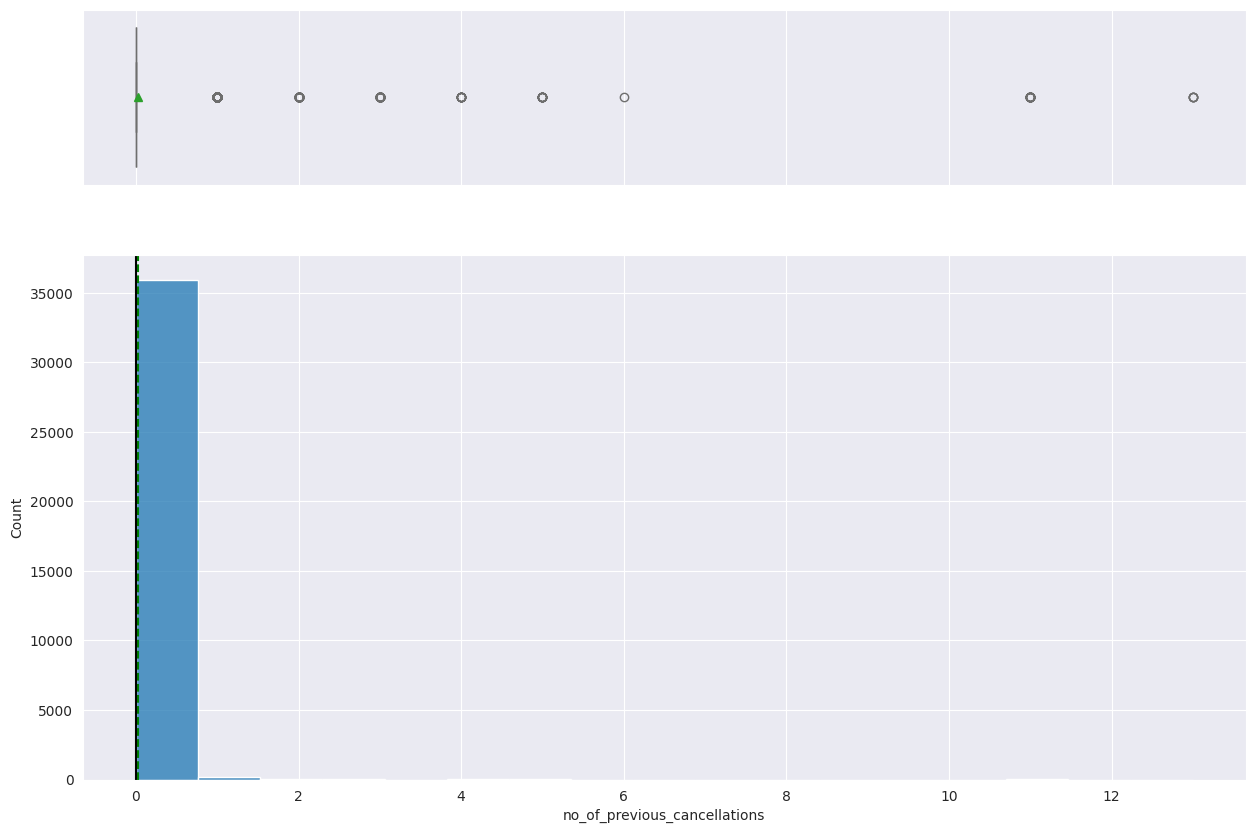

In [123]:
histogram_boxplot(data, "no_of_previous_cancellations")


Most customers **never canceled before.**

A small group canceled multiple times **(up to 13).**

These customers have **a high risk** of canceling again.

### 4. no_of_previous_bookings_not_canceled

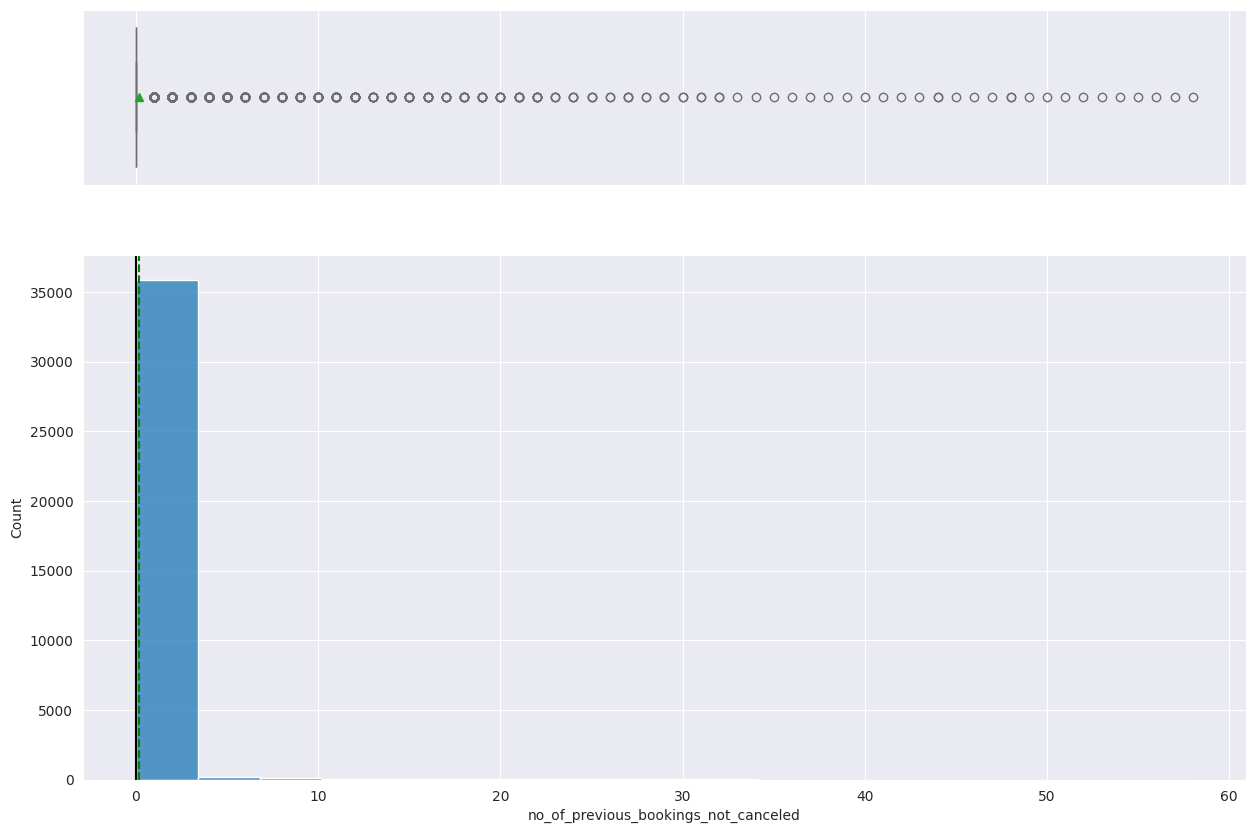

In [124]:
histogram_boxplot(data, "no_of_previous_bookings_not_canceled")


Many customers have **no prior** bookings.

Some customers have **20–50+** successful bookings.

These loyal customers **rarely cancel.**

In [125]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### Observations on number of adults

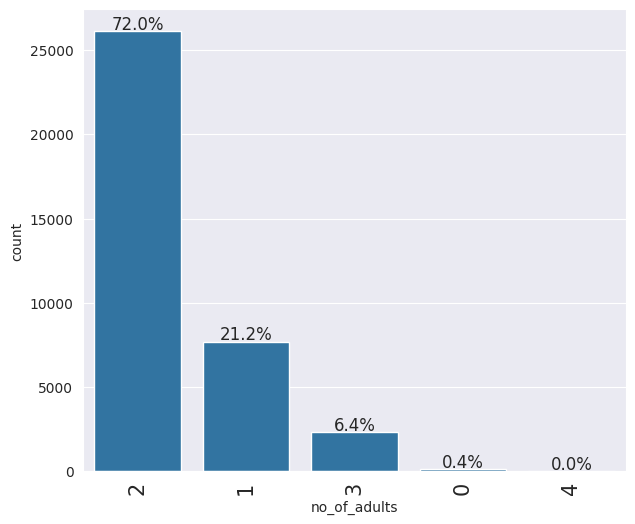

In [126]:
labeled_barplot(data, "no_of_adults", perc=True)


Most bookings include** 2 adults.**

Single‑adult bookings are** less common.**

Bookings with 3–4 adults exist but are rare.

Very few bookings have** 0 adults — these may be special cases** (e.g., children-only bookings or data entry issues).

The distribution is simple and clean, with no unusual patterns.

### no_of_children

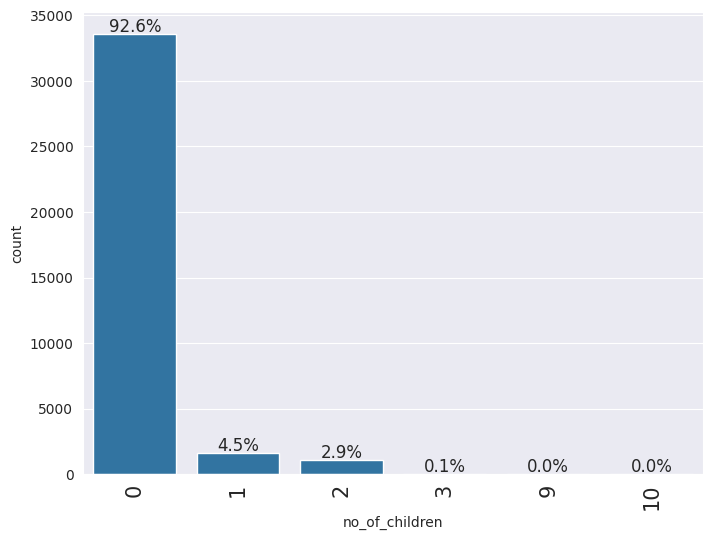

In [127]:
labeled_barplot(data, "no_of_children", perc=True)


Most bookings have **no children.**

Very few bookings include **3+** children.



### no_of_week_nights

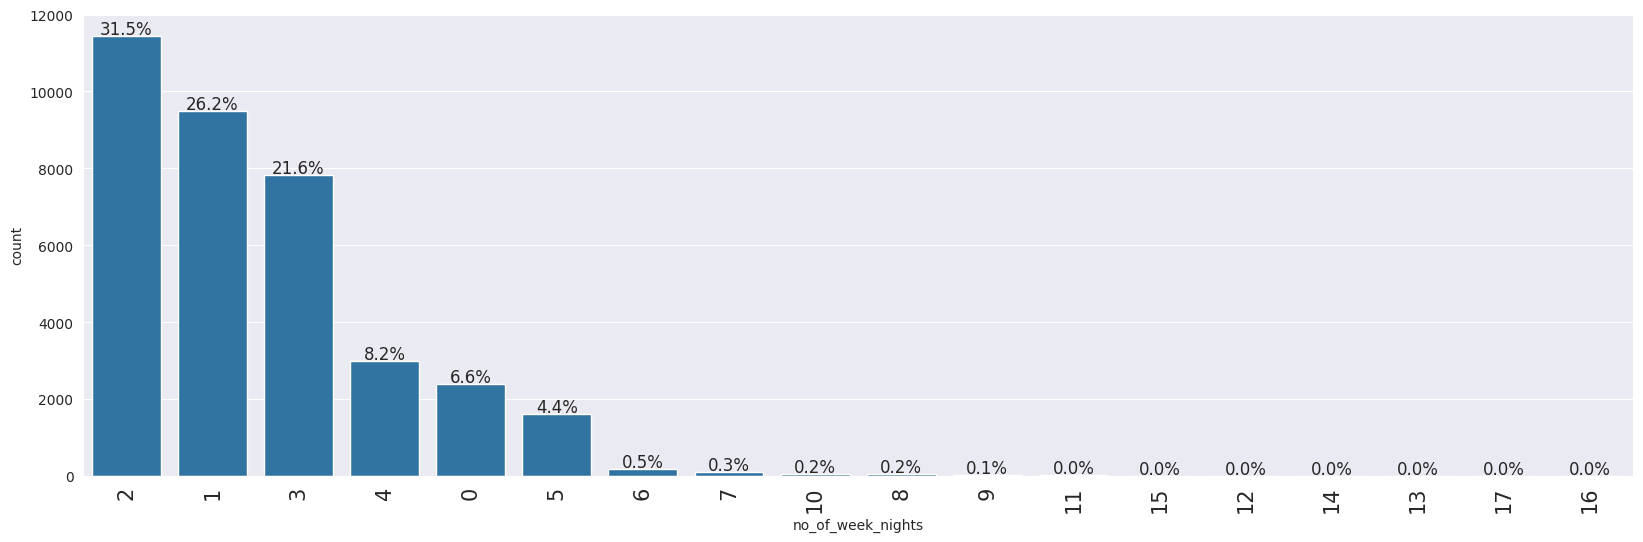

In [128]:
labeled_barplot(data, "no_of_week_nights", perc=True)


Most stays are **1–3 nights.**

Very **long stays (10+ nights)** are rare but valid.

### no_of_weekend_nights

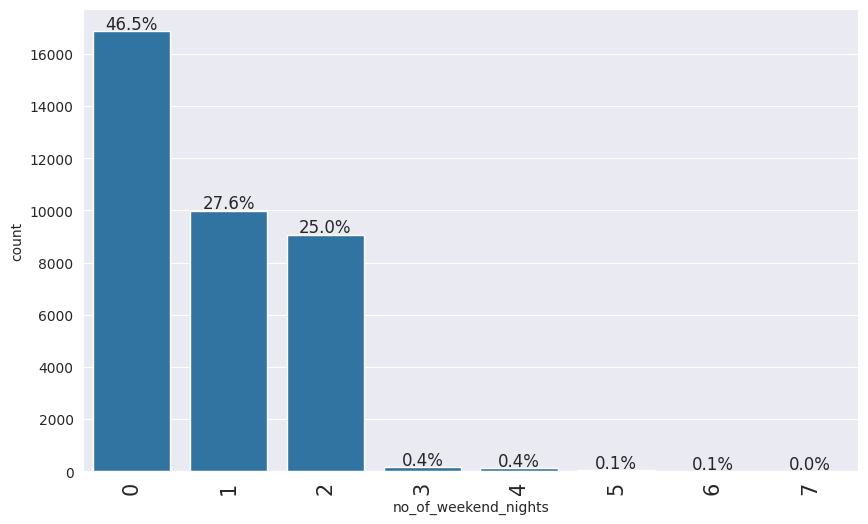

In [129]:
labeled_barplot(data, "no_of_weekend_nights", perc=True)


Most guests stay **0–2 weekend nights.**

Long weekend stays **(5–7 nights) are unusual.**

### required_car_parking_space

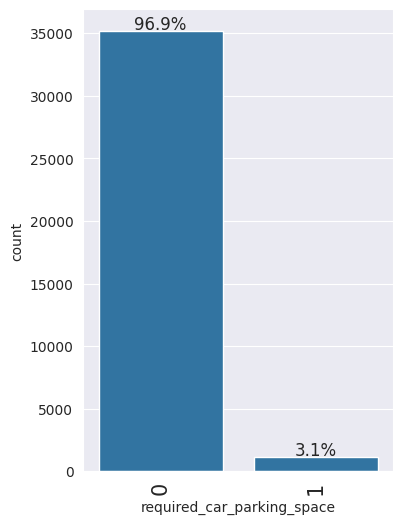

In [130]:
labeled_barplot(data, "required_car_parking_space", perc=True)


Only **~3% of guests** request parking.

Parking is **not a major factor** for most customers.

### type_of_meal_plan

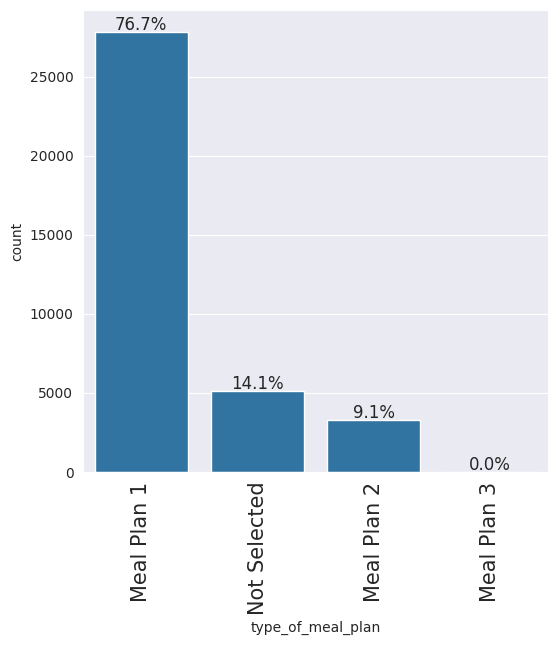

In [131]:
labeled_barplot(data, "type_of_meal_plan", perc=True)


Meal Plan **1 (breakfast)** is the most common.

Full board is rare.

### room_type_reserved

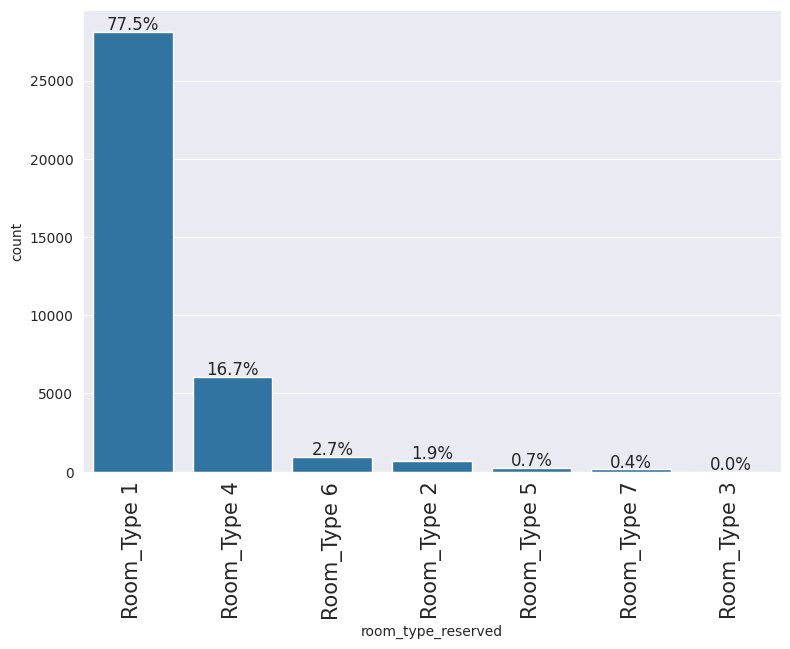

In [132]:
labeled_barplot(data, "room_type_reserved", perc=True)


Room types **are encoded.**

Some room types are much more popular than others.

### arrival_month **(what are the busiest months in the hotel?)**

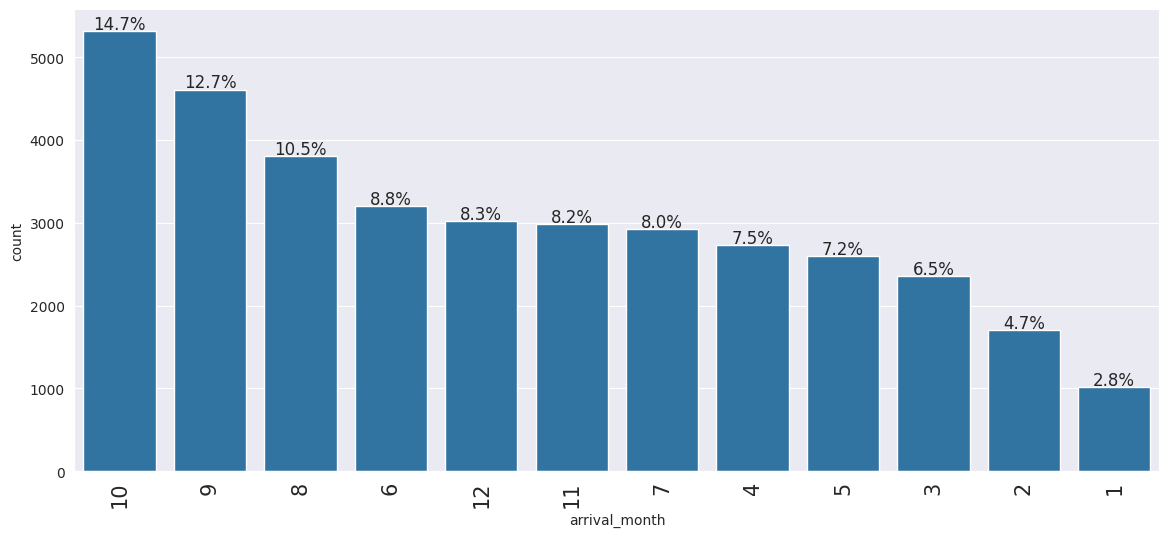

In [133]:
labeled_barplot(data, "arrival_month", perc=True)


### Bookings peak in summer and authem(August - October).

Winter months have fewer bookings.

### market_segment_type **(which market segment do most of the guests come from?)**

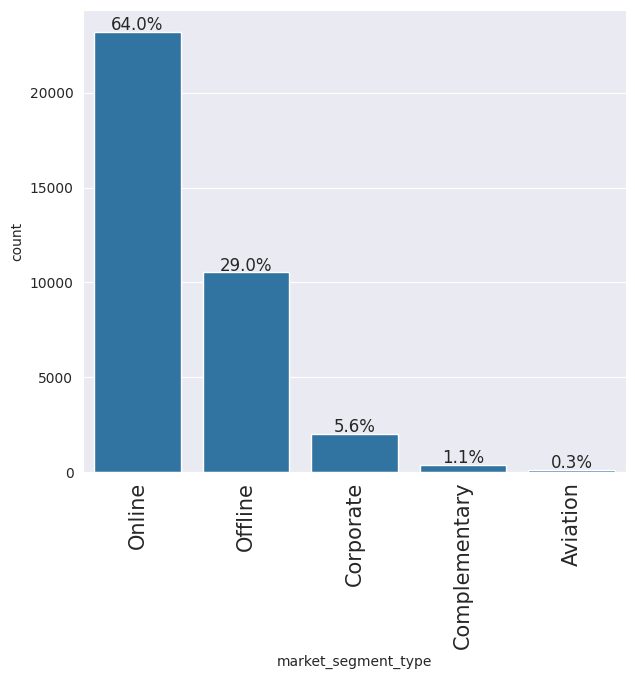

In [134]:
labeled_barplot(data, "market_segment_type", perc=True)


Online channels **dominate.**

Corporate and offline bookings are smaller segments.

### no_of_special_requests

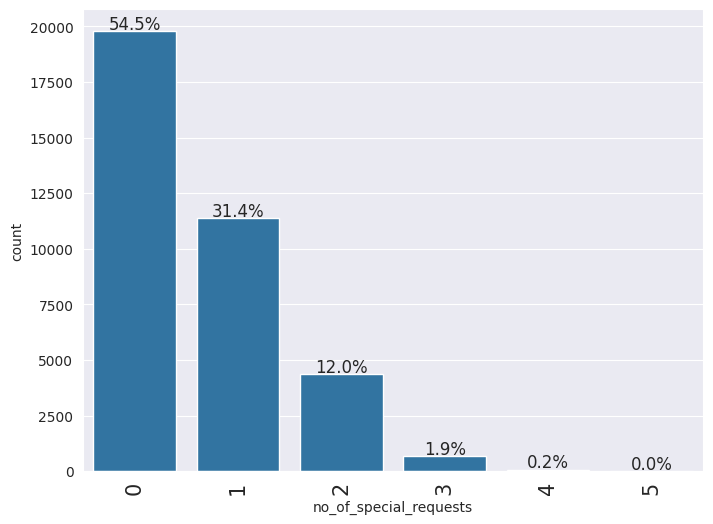

In [135]:
labeled_barplot(data, "no_of_special_requests", perc=True)


Most guests make **0–1 special requests.**

Guests with many requests tend to be more committed and **less likely to cancel.**

### booking_status **(what percentage of bookings are canceled?)**

In [136]:
data["booking_status"].value_counts(normalize=True)

,proportion
booking_status,
Not_Canceled,0.67236
Canceled,0.32764


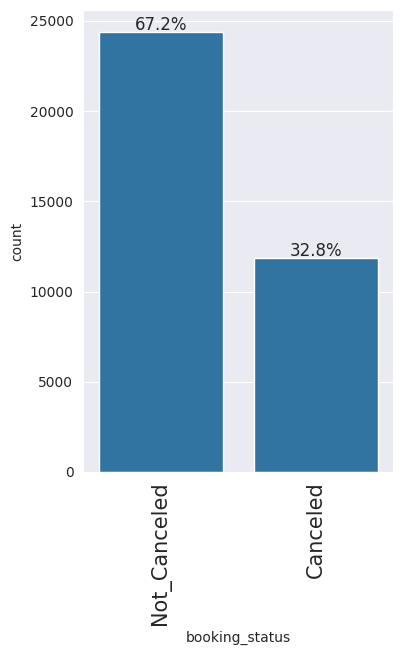

In [137]:
labeled_barplot(data, "booking_status", perc=True)


### A large portion of bookings **are canceled(~32.8%)**

This confirms the business **needs  a prediction model.**

### **Let's encode Canceled bookings to 1 and Not_Canceled as 0 for further analysis**

In [138]:
data["booking_status"] = data["booking_status"].apply(
    lambda x: 1 if x == "Canceled" else 0
)


## Outlier Detection for Lead time

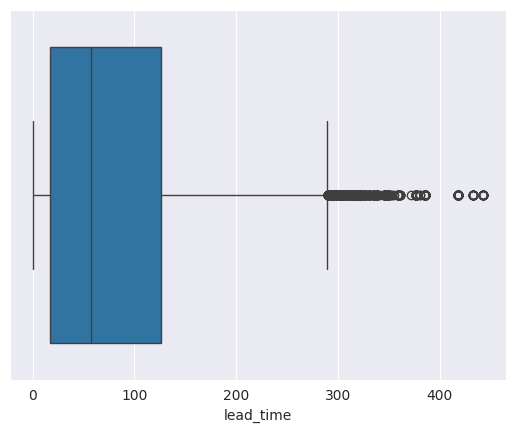

In [139]:
sns.boxplot(data=data, x="lead_time")
plt.show()

The variable lead_time contains several extreme values and a **long right tail** distribution.

This indicates the presence of outliers, which **may negatively affect** some machine learning models, particularly Logistic Regression.

Therefore, outlier treatment will be considered during the data preprocessing stage.

# 2. Bivariate Analysis

## Correlation Heatmap

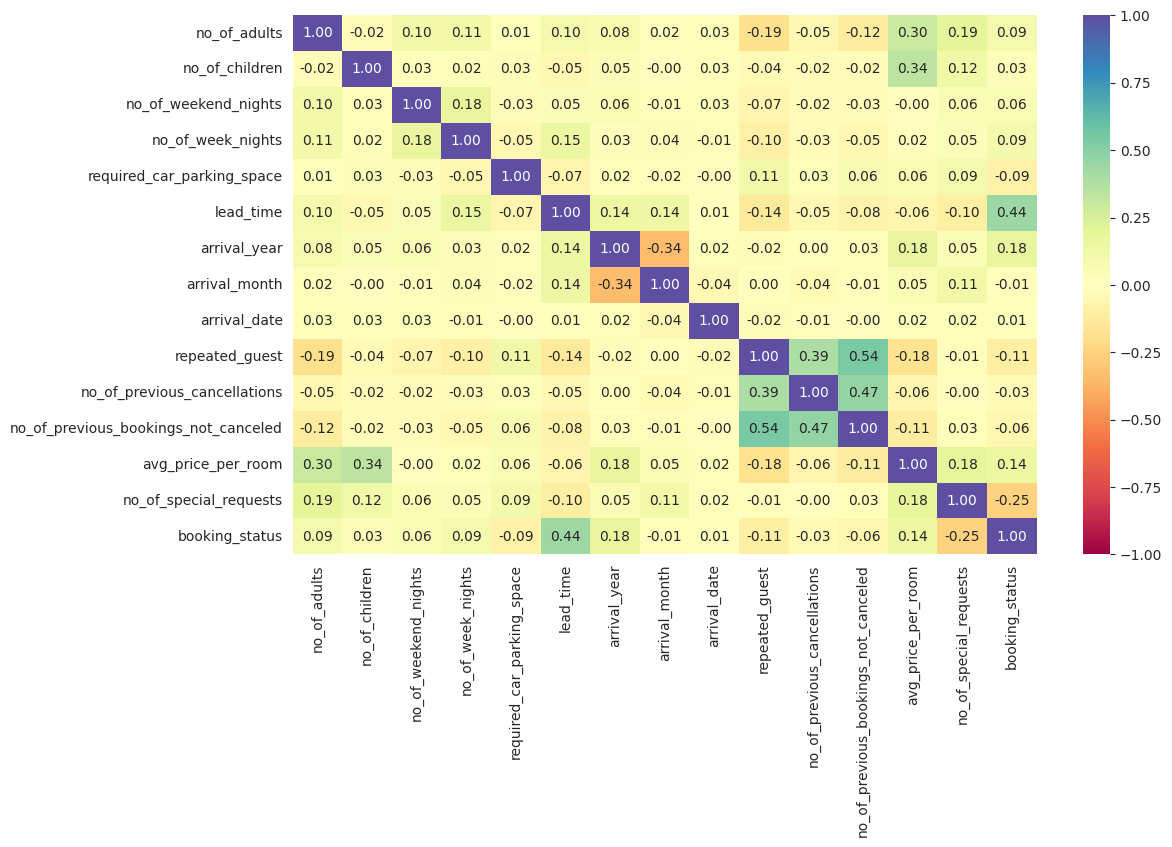

In [140]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

Most numeric features **show weak correlations,** meaning they are not strongly related to each other.

* **number of previous booking not canceled shows a strong positive** correlation

* **repieted_guests shows  moderate correlation with** cancellation

* **lead_time shows moderate correlationwith** cancellation — customers who **book far in advance tend to cancel more.**

* **no_of_special_requests has a negative correlation** with cancellation — guests with more requests tend to show up.

Heatmap helps identify which features may be useful predictors for the model.

## Function: distribution_plot_wrt_target

In [141]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0])

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
    )

    plt.tight_layout()
    plt.show()

This function helps compare how a feature behaves for canceled vs. not‑canceled bookings.

Histograms show shape differences between the two groups.

Boxplots show median differences and spread differences.

If **the two distributions look very different → the feature is useful for prediction.**

If they look almost identical → the feature is not very informative.

## stacked_barplot()

In [142]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """

    # Count unique categories for figure size
    count = data[predictor].nunique()

    # Crosstab for counts
    tab1 = pd.crosstab(data[predictor], data[target], margins=True)
    print(tab1)
    print("-" * 120)

    # Crosstab for percentages
    tab = pd.crosstab(data[predictor], data[target], normalize="index")

    # Ensure columns appear in fixed order: 0 then 1
    if 0 in tab.columns and 1 in tab.columns:
        tab = tab[[0, 1]]
    elif 0 in tab.columns:
        tab = tab[[0]]
    elif 1 in tab.columns:
        tab = tab[[1]]

    # Plot
    ax = tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5),
                  color=["#1f77b4", "#ff7f0e"])  # fixed blue + orange

    # Legend logic
    if data[target].nunique() == 2:
        plt.legend(["Not Canceled (0)", "Canceled (1)"],
                   loc="upper left", bbox_to_anchor=(1, 1))
    elif data[target].nunique() == 1:
        only_class = data[target].unique()[0]
        label = "Not Canceled (0)" if only_class == 0 else "Canceled (1)"
        plt.legend([label], loc="upper left", bbox_to_anchor=(1, 1))
    else:
        plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

    plt.xlabel(predictor)
    plt.ylabel("Percentage")
    plt.title(f"Booking Status Distribution by {predictor}")
    plt.tight_layout()
    plt.show()


Stacked barplots show how categories differ between canceled and non‑canceled bookings.

If **one category has a much higher cancellation rate → it is a strong predictor.**

If all categories look similar → the feature is weak.

This method is especially useful for categorical variables (meal plan, room type, market segment).

### 1. Prices across market segments

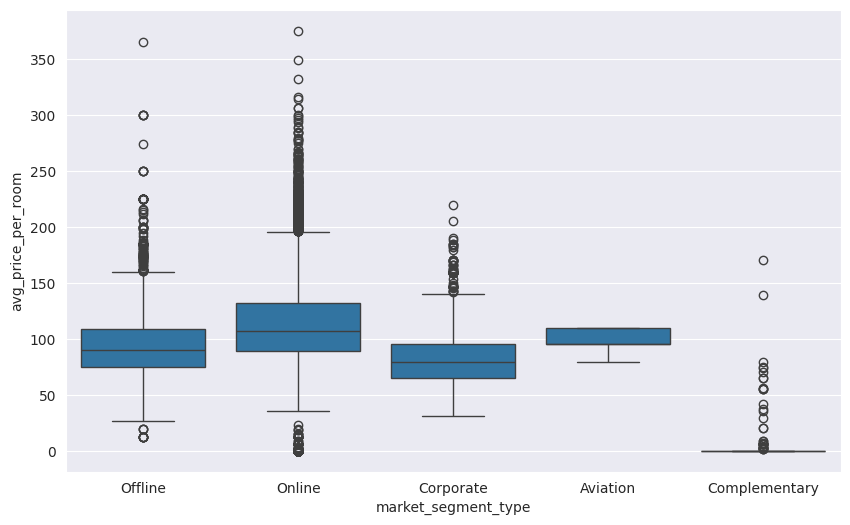

In [143]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="market_segment_type", y="avg_price_per_room")
plt.show()


**Corporate and Complementary s**egments often have lower prices.

**Online ** segment show **higher price variability.**

Some segments consistently pay more, which may influence cancellation behavior.

### 2. Booking status across market segments

booking_status           0      1    All
market_segment_type                     
Aviation                88     37    125
Complementary          391      0    391
Corporate             1797    220   2017
Offline               7375   3153  10528
Online               14739   8475  23214
All                  24390  11885  36275
------------------------------------------------------------------------------------------------------------------------


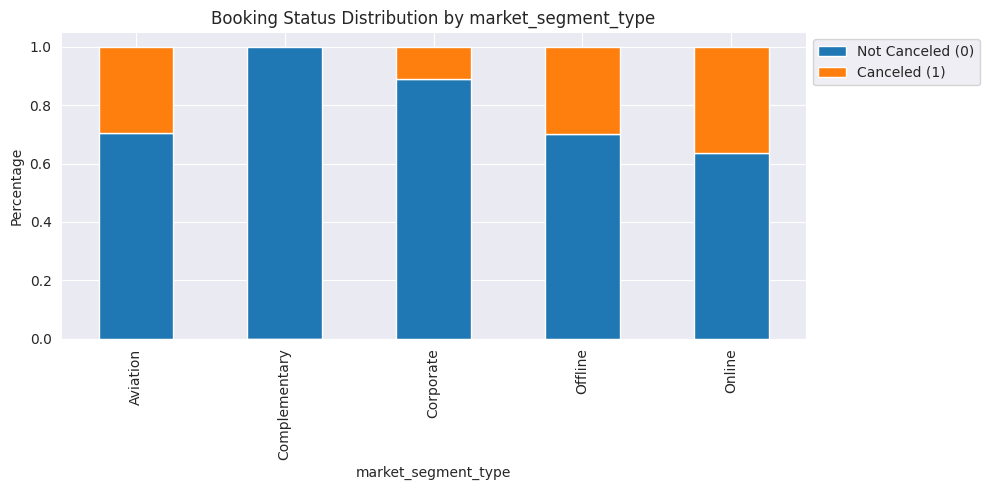

In [144]:
stacked_barplot(data, "market_segment_type", "booking_status")


**Online segment** usually has the **highest cancellation** rate.

**Corporate guests rarely cancel.**


### 3. Special requests vs booking status

booking_status              0      1    All
no_of_special_requests                     
0                       11232   8545  19777
1                        8670   2703  11373
2                        3727    637   4364
3                         675      0    675
4                          78      0     78
5                           8      0      8
All                     24390  11885  36275
------------------------------------------------------------------------------------------------------------------------


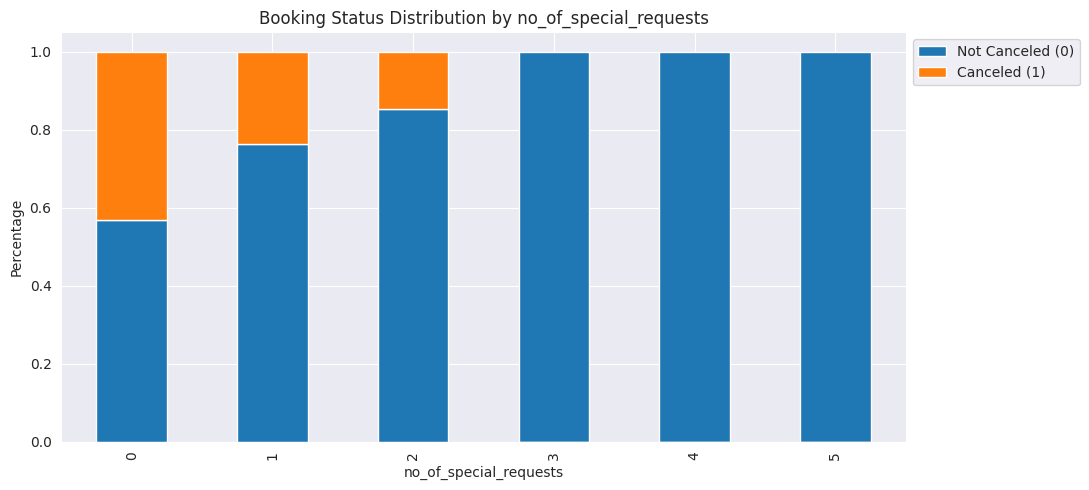

In [145]:
stacked_barplot(data, "no_of_special_requests", "booking_status")


**Guests with 0 special** requests **cancel the most.**

**Guests with 2+** special requests **rarely cancel —** they are more committed.

Special requests are a strong negative predictor of cancellation.

### 4. Special requests vs price

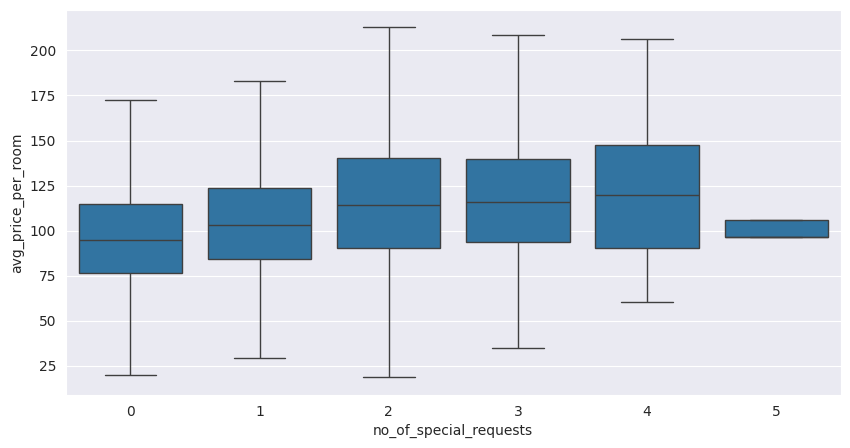

In [146]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="no_of_special_requests", y="avg_price_per_room", showfliers=False)
plt.show()


**Guests with more special** requests tend to book **slightly more expensive rooms.**

However, the effect is not very strong.

Price is not the main driver of special requests.

### 5. avg_price_per_room vs booking_status

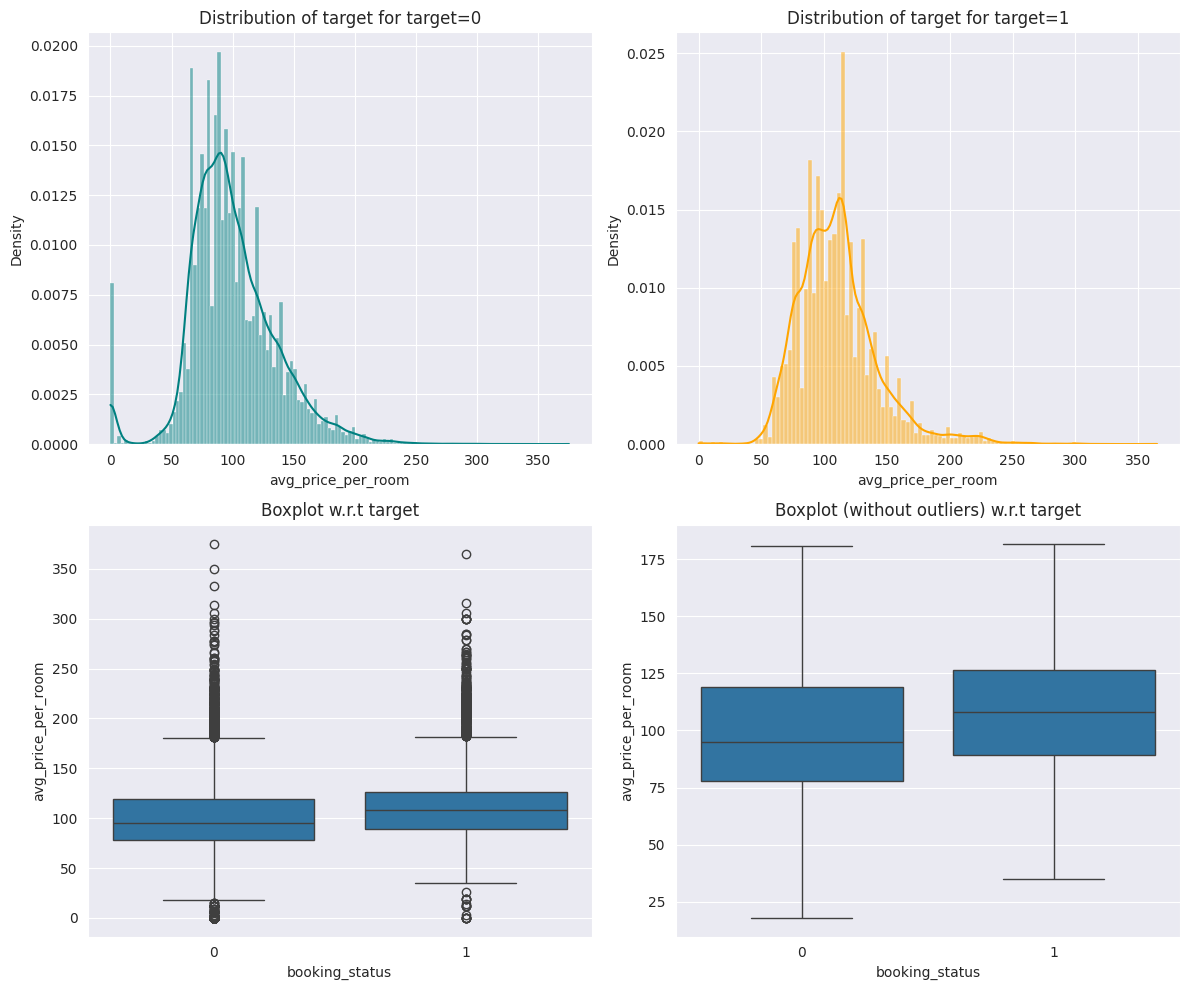

In [147]:
distribution_plot_wrt_target(data, "avg_price_per_room", "booking_status")


**Canceled bookings tend to have higher average prices.**

Guests who pay more are more likely to cancel — possibly due to price sensitivity.

This feature is important for prediction.

## 6. lead_time vs booking_status

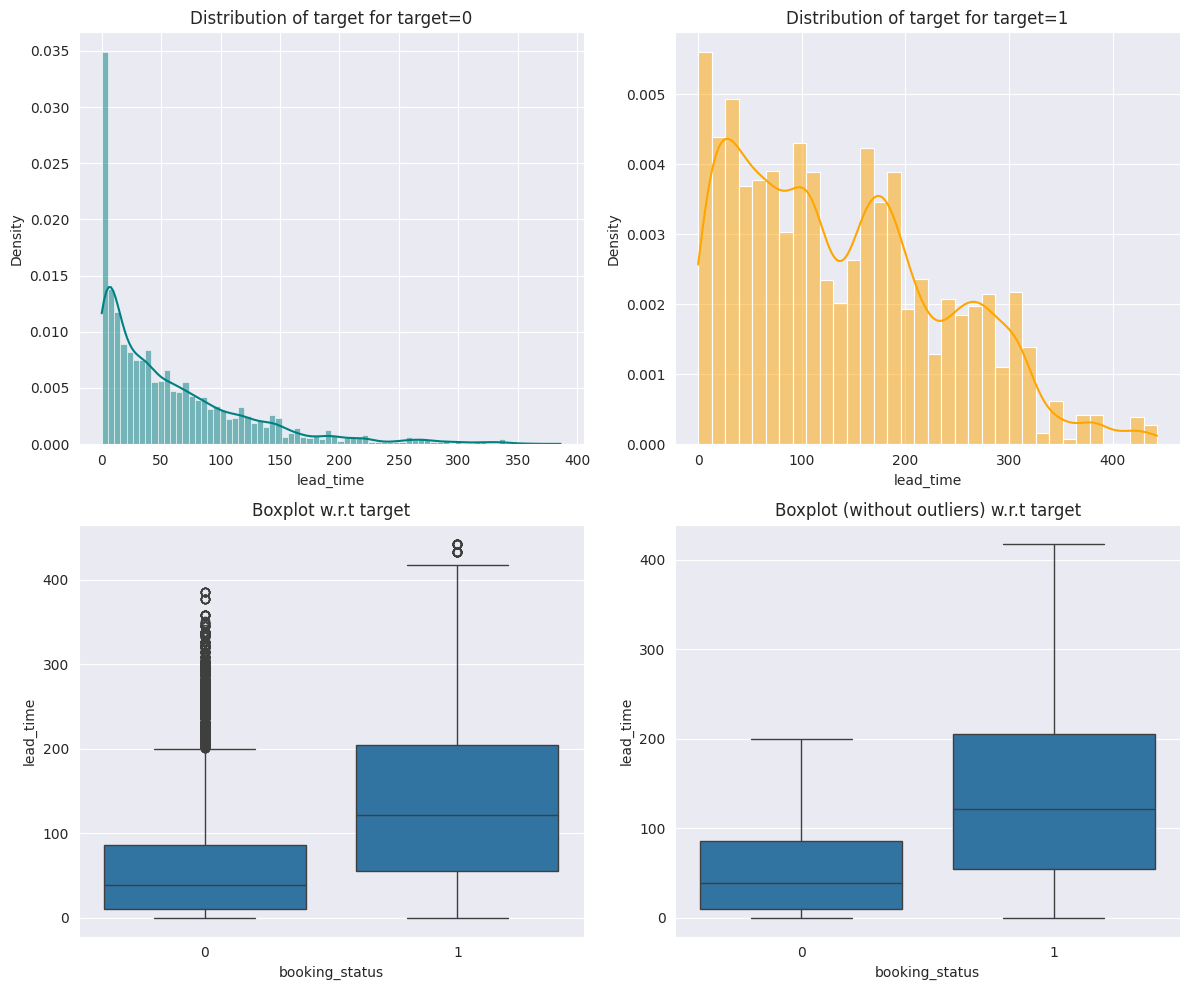

In [148]:
distribution_plot_wrt_target(data, "lead_time", "booking_status")


**Long lead times strongly correlate with cancellations.**

Guests who book far in advance are more likely **to change plans.**

**Short lead times rarely cancel** — these are last‑minute, committed guests.

## 7. FAMILY ANALYSIS — Families and Booking Status

In [149]:
# Create a new column for total family members
family_data = data[(data["no_of_children"] >= 0) & (data["no_of_adults"] > 1)]
family_data.shape



(28441, 18)

booking_status            0     1    All
no_of_family_members                    
2                     15506  8213  23719
3                      2425  1368   3793
4                       514   398    912
5                        10     5     15
11                        0     1      1
12                        1     0      1
All                   18456  9985  28441
------------------------------------------------------------------------------------------------------------------------


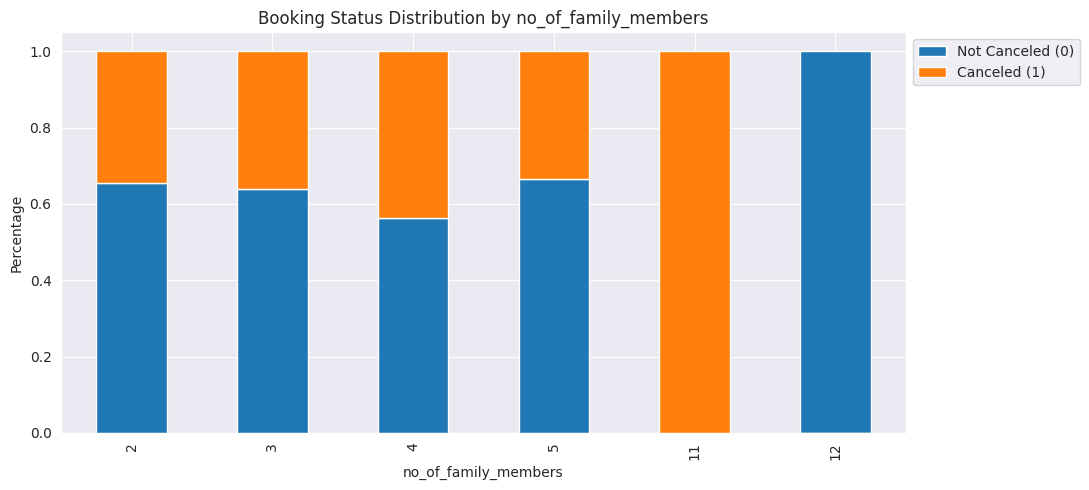

In [200]:
family_data = data[(data["no_of_children"] >= 0) & (data["no_of_adults"] > 1)]
family_data["no_of_family_members"] = (
    family_data["no_of_adults"] + family_data["no_of_children"]
)

# Call the stacked_barplot function with the updated data DataFrame
stacked_barplot(family_data, "no_of_family_members", "booking_status")

Larger families ( 12 members) **not cancel.**

Familes with 2 to  5 peaole gave tendency to cancel.


**Family size is a strong indicator** of booking commitment.

### Let's do a similar analysis for the customer who stay for at least a day at the hotel.

In [151]:
stay_data = data[(data["no_of_week_nights"] > 0) & (data["no_of_weekend_nights"] > 0)]
stay_data.shape

(17094, 18)

In [152]:
stay_data["total_days"] = (
    stay_data["no_of_week_nights"] + stay_data["no_of_weekend_nights"]
)

booking_status      0     1    All
total_days                        
2                1301   639   1940
3                3689  2183   5872
4                2977  1387   4364
5                1593   738   2331
6                 566   465   1031
7                 590   383    973
8                 100    79    179
9                  58    53    111
10                 51    58    109
11                 24    15     39
12                  9    15     24
13                  3    15     18
14                  5    27     32
15                  5    26     31
16                  1     5      6
17                  1     4      5
18                  0     3      3
19                  1     5      6
20                  3     8     11
21                  1     3      4
22                  0     2      2
23                  1     1      2
24                  0     1      1
All             10979  6115  17094
------------------------------------------------------------------------------------------

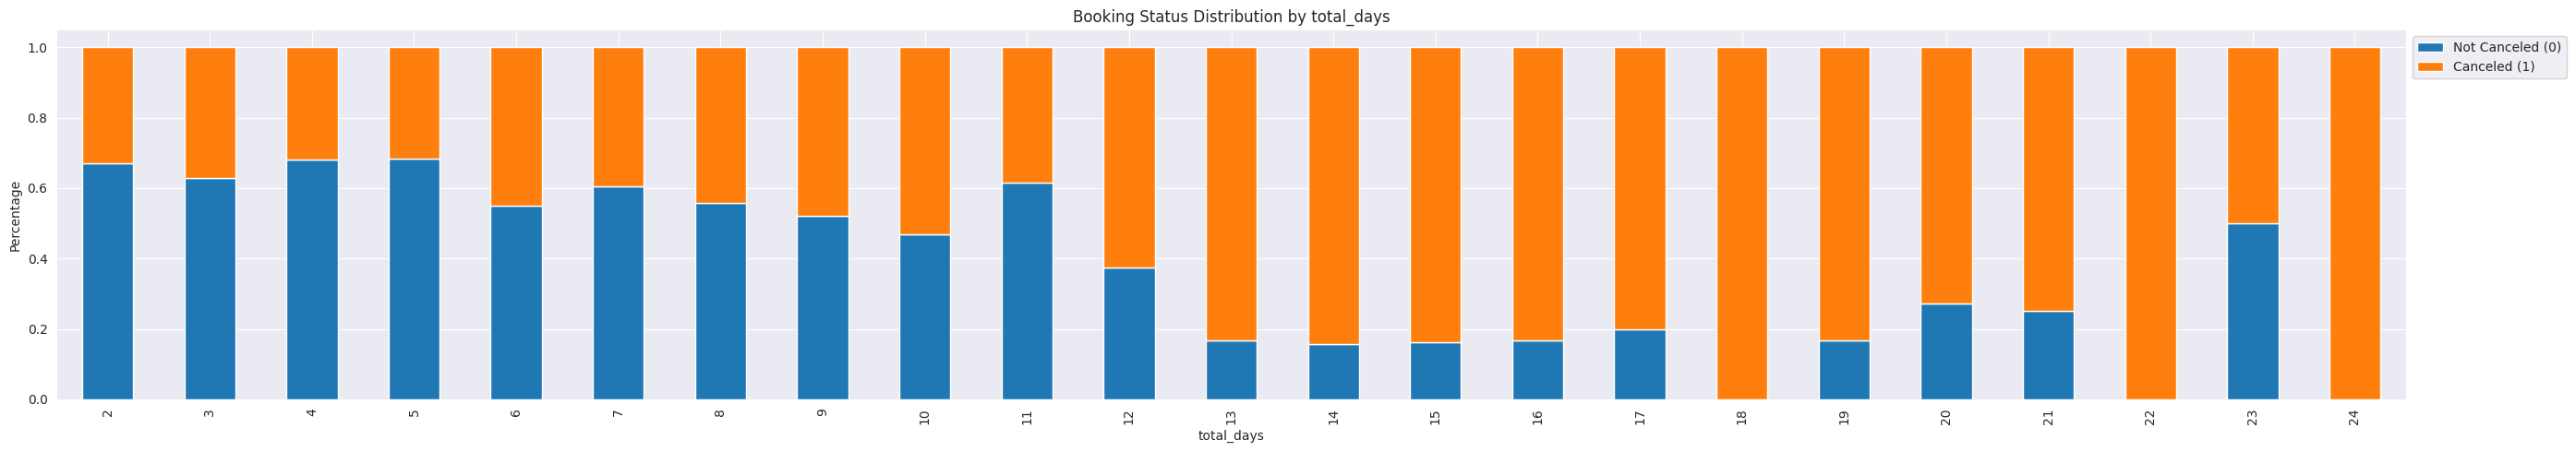

In [153]:
stacked_barplot(stay_data, "total_days", "booking_status")


Guests staying **2-11 days** **cancel more frequently.**

Longer stays (12+ days) have very** low cancellation rates.**

Vacation‑type stays **(longer trips) are more stable.**

Short stays are often business trips → more cancellations.

### REPEATED GUESTS — Loyalty and Cancellations

In [154]:
repeated_cancel = pd.crosstab(
    data["repeated_guest"],
    data["booking_status"],
    normalize="index"
) * 100

repeated_cancel

booking_status,0,1
repeated_guest,,
0,66.41958,33.58042
1,98.27957,1.72043


booking_status      0      1    All
repeated_guest                     
0               23476  11869  35345
1                 914     16    930
All             24390  11885  36275
------------------------------------------------------------------------------------------------------------------------


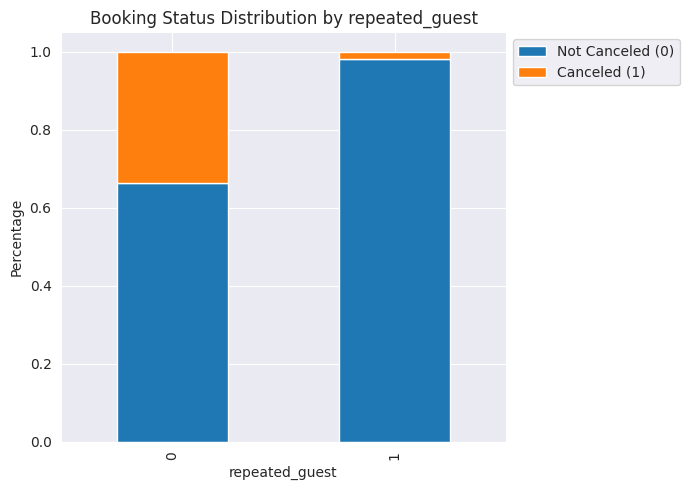

In [155]:
stacked_barplot(data, "repeated_guest", "booking_status")


**Repeated guests almost never cancel**.

New guests cancel much more often.

Loyal customers are low‑risk and valuable for the hotel.

This **feature is a strong negative predictor of cancellation.**

### BUSIEST MONTHS ANALYSIS — Which months bring the most guests?

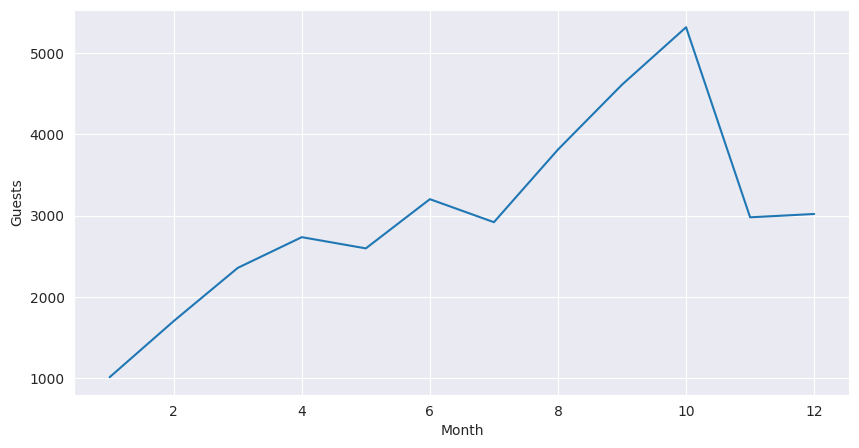

In [156]:
# grouping the data on arrival months and extracting the count of bookings
monthly_data = data.groupby(["arrival_month"])["booking_status"].count()

# creating a dataframe with months and count of customers in each month
monthly_data = pd.DataFrame(
    {"Month": list(monthly_data.index), "Guests": list(monthly_data.values)}
)

# plotting the trend over different months
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_data, x="Month", y="Guests")
plt.show()

The hotel is **busiest during summer and authem months ( Augus-October).**

There is a noticeable dip in winter months, **especially January and February.**

**Spring and early summer show moderate booking levels.**

This seasonal pattern is typical for vacation‑driven hotels.

Understanding peak months helps with pricing, staffing, and cancellation prediction.

## Percentage of bookings canceled in each month

booking_status      0      1    All
arrival_month                      
1                 990     24   1014
2                1274    430   1704
3                1658    700   2358
4                1741    995   2736
5                1650    948   2598
6                1912   1291   3203
7                1606   1314   2920
8                2325   1488   3813
9                3073   1538   4611
10               3437   1880   5317
11               2105    875   2980
12               2619    402   3021
All             24390  11885  36275
------------------------------------------------------------------------------------------------------------------------


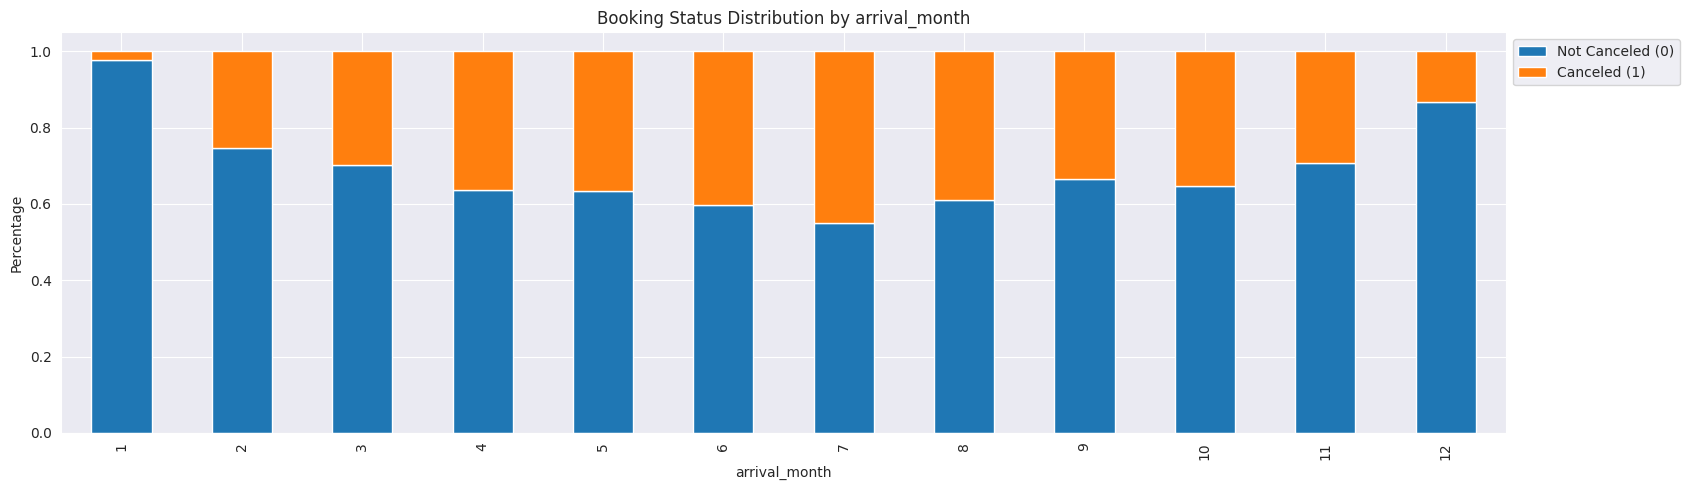

In [157]:
stacked_barplot(data, "arrival_month", "booking_status")


* **Summer months (June–August) have the highest number of cancellations** because demand is high and plans change more often.

* **Winter months (January–February) show the lowest cancellation** rates.

 * Spring and fall months show moderate cancellation behavior.

Seasonality strongly affects cancellation patterns.

### Price variation across months

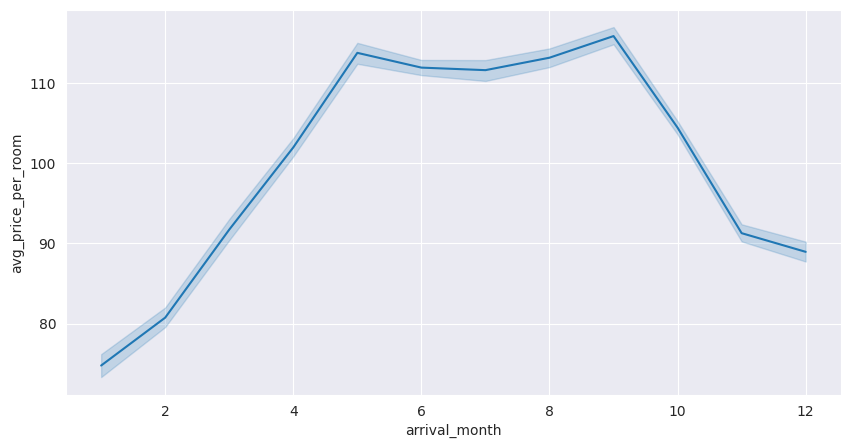

In [158]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=data, x="arrival_month", y="avg_price_per_room")
plt.show()


**Prices peak during summer months** due to high demand.

**Prices drop significantly in winter months, especially January**.

Spring and early fall show moderate pricing.

This seasonal price pattern explains why cancellations are also seasonal.

Hotels adjust prices dynamically based on demand, holidays, and travel patterns.

## Final EDA Conclusions

The exploratory analysis revealed several important business patterns:

- Online bookings dominate hotel reservations and also show higher cancellation behavior.
- Customers with longer lead times are significantly more likely to cancel bookings.
- Repeated guests are much more reliable and cancel less frequently.
- Guests with special requests appear more committed to their stay.
- Previous customer cancellation behavior is strongly associated with future cancellations.
- Room prices vary significantly across market segments, confirming dynamic pricing behavior.

These findings suggest that customer behavior, booking timing, and booking channel are important predictors of hotel booking cancellations and should be useful features for predictive modeling.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [159]:
# Creating total_nights feature
data["total_nights"] = data["no_of_week_nights"] + data["no_of_weekend_nights"]

# Dropping the original columns
data = data.drop(["no_of_week_nights", "no_of_weekend_nights"], axis=1)


**Combining weekday and weekend nights into a single feature reduces noise and simplifies the model.**

total_nights is more predictive than the two separate columns.

Removing the original columns prevents multicollinearity and improves model stability.

This transformation belongs in the feature engineering stage of preprocessing, before encoding.

## Checking Missing Values

In [160]:
# Checking missing values

missing_values = data.isnull().sum()

missing_values

,0
no_of_adults,0
no_of_children,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0
arrival_month,0
arrival_date,0
market_segment_type,0


The dataset contains no significant missing values.

Therefore, no missing value imputation is required.

No significant duplicate rows were detected.

### OUTLIER CHECK — Detecting Outliers Using Boxplots

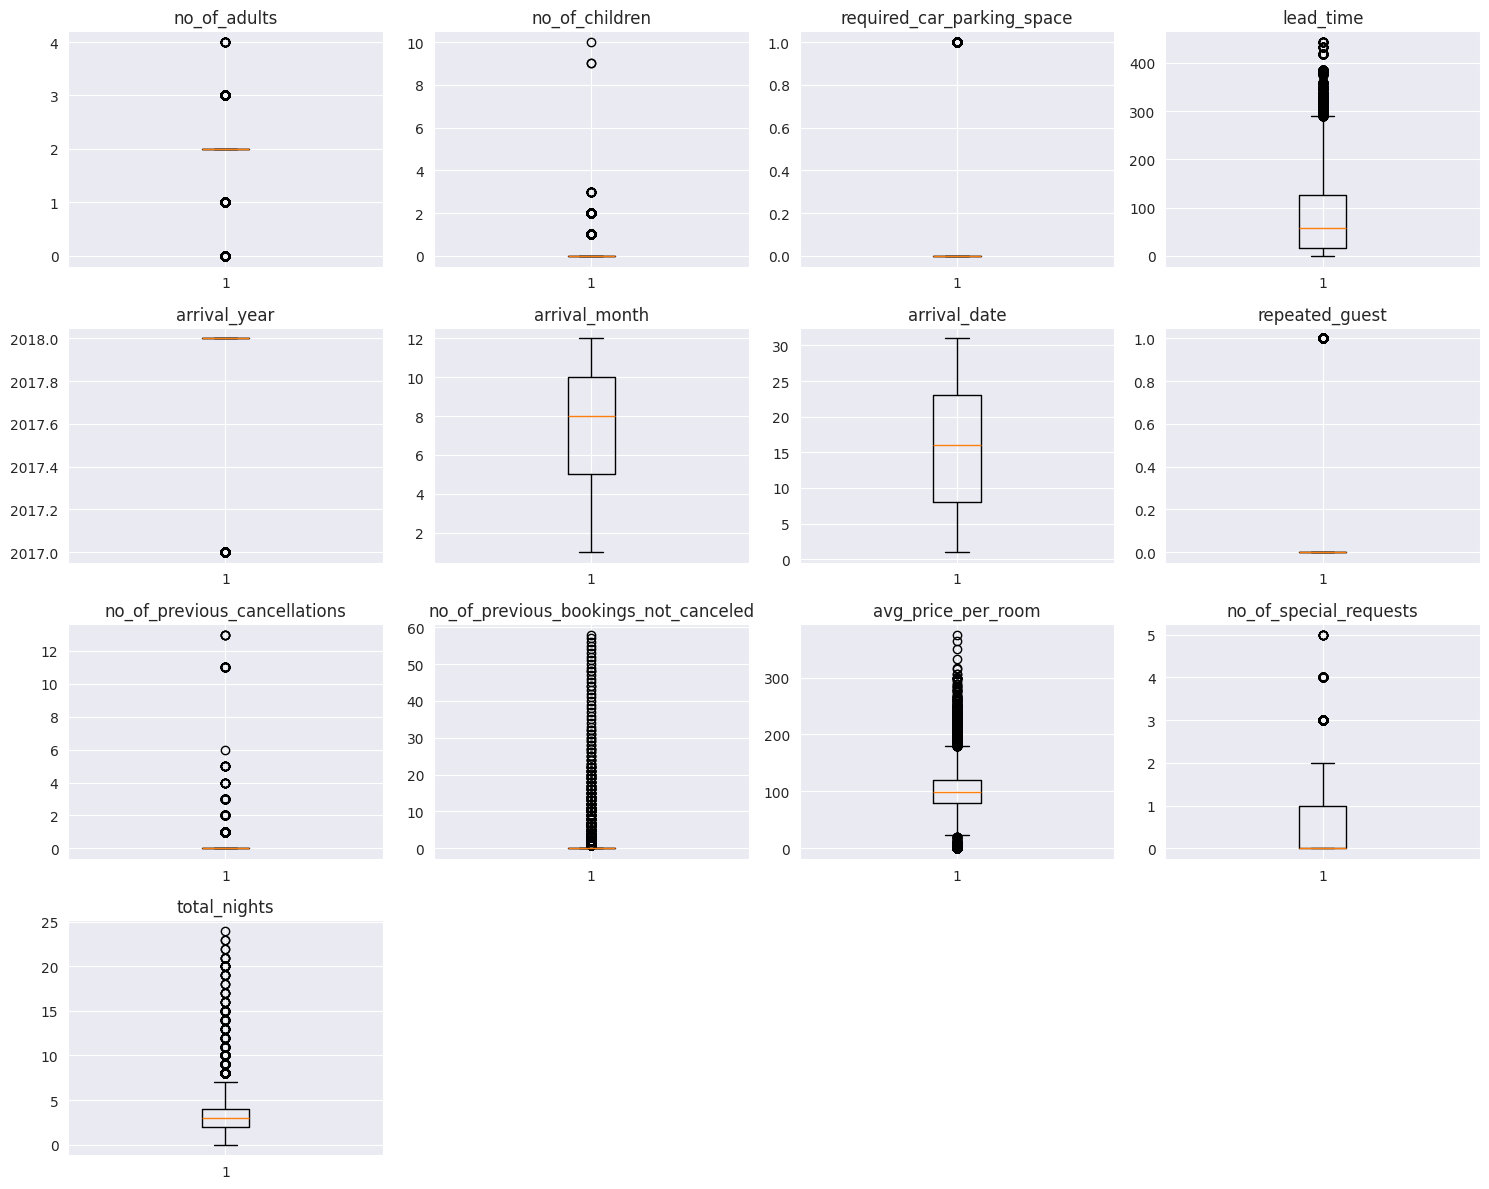

In [161]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
# dropping booking_status
if "booking_status" in numeric_columns:
    numeric_columns.remove("booking_status")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

## Outlier Treatment using IQR Method

Extreme values in **the lead_time** variable may negatively influence model stability and coefficient estimation.

To reduce the effect of extreme observations, the Interquartile Range (IQR) method was applied to cap extreme values.

In [162]:
# Calculating IQR for lead_time

Q1 = data["lead_time"].quantile(0.25)
Q3 = data["lead_time"].quantile(0.75)

IQR = Q3 - Q1

# Defining lower and upper bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping outliers

data["lead_time"] = np.where(
    data["lead_time"] > upper_bound,
    upper_bound,
    data["lead_time"]
)

data["lead_time"] = np.where(
    data["lead_time"] < lower_bound,
    lower_bound,
    data["lead_time"]
)

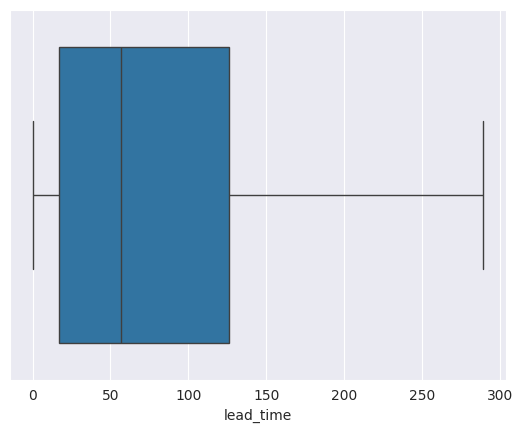

In [163]:
sns.boxplot(data=data, x="lead_time")
plt.show()

After applying IQR-based capping,
the extreme values in lead_time **were reduced successfully.**

**The overall distribution of the variable was preserved,**
while the influence of extreme observations became less significant.

This preprocessing step may help improve model stability
and reduce potential convergence issues in Logistic Regression.

Although some outliers are present, we decided NOT to remove them.

This is because:

hotel bookings naturally contain extreme cases
expensive rooms are realistic
long lead times are realistic
removing them could reduce business realism

Additionally:

Logistic Regression is less sensitive to outliers than some other algorithms

removing too many observations may reduce important business information

## Model Building
Model evaluation criterion

Model can make wrong predictions as:

* Predicting a customer will not cancel their booking but in reality, the customer will cancel their booking.

* Predicting a customer will cancel their booking but in reality, the customer will not cancel their booking.
Which case is more important?
Both the cases are important as:

If we predict that a booking will not be canceled and the booking gets canceled then the hotel will lose resources and will have to bear additional costs of distribution channels.

If we predict that a booking will get canceled and the booking doesn't get canceled the hotel might not be able to provide satisfactory services to the customer by assuming that this booking will be canceled. This might damage the brand equity.

How to reduce the losses?
Hotel would want F1 Score to be maximized, greater the F1 score higher are the chances of minimizing False Negatives and False Positives.
First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

The **model_performance_classification_statsmodels function** will be used to check the model performance of models.

**The confusion_matrix_statsmodels **function will be used to plot the confusion matrix.

In [164]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [165]:
# defining a function to plot the confusion_matrix of a classification model


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Logistic Regression (with statsmodels library)

### Data Preparation for modeling (Logistic Regression)
We want to predict which bookings will be canceled.

Before we proceed to build a model, we'll have to encode categorical features.

We'll split the data into train and test to be able to evaluate the model that we build on the train data.

## Define Features and Target

In [166]:
X = data.drop(["booking_status"], axis=1)
Y = data["booking_status"]


## Encoding Categorical Variables

In [167]:
X = pd.get_dummies(X, drop_first=True)


Train-Test Split

In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=1,
    stratify=Y
)

In [169]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (25392, 26)
Shape of test set :  (10883, 26)
Percentage of classes in training set:
booking_status
0   0.67238
1   0.32762
Name: proportion, dtype: float64
Percentage of classes in test set:
booking_status
0   0.67233
1   0.32767
Name: proportion, dtype: float64


**Adding a constant ensures** the logistic regression model includes an intercept term.

**Dummy encoding converts categorical variables into numeric format **so the model can use them.

drop_first=True prevents multicollinearity by removing redundant dummy columns.

**A 70:30 train‑test split is standard **for classification tasks.

This block is the true encoding step — it prepares the dataset for modeling.

Stratification preserves the same class distribution in both train and test datasets.

### Final Preprocessing Summary

**Completed preprocessing steps:**

checked missing values
checked duplicates
removed Booking_ID
engineered new features
inspected outliers
encoded categorical variables
split data
scaled features

The dataset is now ready for **Logistic Regression modeling.**

## EDA

- It is a good idea to explore the data once again after manipulating it.

STEP 1 — Check Final Dataset Shape

In [170]:
# Shape after preprocessing
X.shape

(36275, 26)

The number of columns increased after One-Hot Encoding because categorical variables were converted into dummy variables.

STEP 2 — Preview Processed Dataset

In [171]:
# First 5 rows after preprocessing
X.head()

,no_of_adults,no_of_children,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_nights,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,0,224.00000,2017,10,2,0,0,0,65.00000,0,3,False,False,False,False,False,False,False,False,False,False,False,True,False
1,2,0,0,5.00000,2018,11,6,0,0,0,106.68000,1,5,False,False,True,False,False,False,False,False,False,False,False,False,True
2,1,0,0,1.00000,2018,2,28,0,0,0,60.00000,0,3,False,False,False,False,False,False,False,False,False,False,False,False,True
3,2,0,0,211.00000,2018,5,20,0,0,0,100.00000,0,2,False,False,False,False,False,False,False,False,False,False,False,False,True
4,2,0,0,48.00000,2018,4,11,0,0,0,94.50000,0,2,False,False,True,False,False,False,False,False,False,False,False,False,True


All categorical variables have been successfully converted into numerical variables.

The dataset is now fully numeric and suitable for Logistic Regression.

STEP 3 — Check Target Variable Balance

In [172]:
# Target variable distribution

Y.value_counts()

,count
booking_status,
0,24390
1,11885


### Visualization

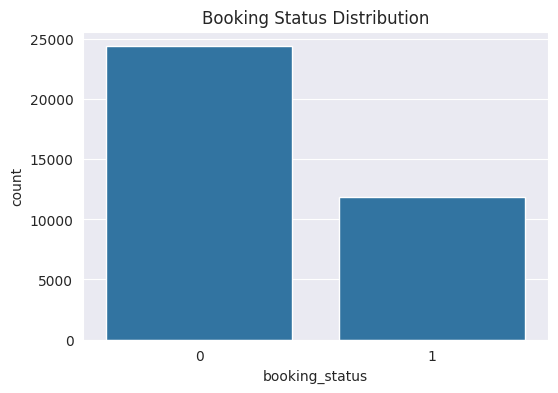

In [173]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=data,
    x="booking_status"
)

plt.title("Booking Status Distribution")

plt.show()

The class distribution remains unchanged after preprocessing.

# CREATE COPIES FOR 2 DIFFERENT MODELS

## 1. Copy for Logistic Regression

In [174]:
# Define numerical columns that need to be scaled
# This list should reflect the numerical features in your X_train and X_test, including 'total_nights'
numerical_cols = ['lead_time', 'avg_price_per_room', 'no_of_previous_cancellations', 'total_nights']


X_train_log = X_train.copy()
X_test_log = X_test.copy()

## 2. Copy for Decision Tree

In [175]:
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

## LOGISTIC REGRESSION PREPROCESSING only for LOGISTIC REGRESSION

## Feature Scaling

In [176]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_log[numerical_cols] = scaler.fit_transform(
    X_train_log[numerical_cols]
)

X_test_log[numerical_cols] = scaler.transform(
    X_test_log[numerical_cols]
)

**Feature scaling** was applied to selected numerical variables using StandardScaler.

Logistic Regression is sensitive to feature magnitude because the optimization process depends on numerical stability.

Scaling places numerical variables on a comparable scale, improves model convergence, stabilizes coefficient estimation, and helps prevent variables with large ranges from dominating the optimization process.



# Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

## STEP 1 — Calculate VIF

Initial VIF Results

In [177]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Selecting numerical features only

X_vif = X_train_log.copy()

# Convert boolean columns to integers (0s and 1s)
# This is necessary because variance_inflation_factor expects numerical input
for col in X_vif.select_dtypes(include='bool').columns:
    X_vif[col] = X_vif[col].astype(int)

# Creating VIF dataframe

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Sorting VIF values

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

vif_data

,Feature,VIF
4,arrival_year,310.37743
25,market_segment_type_Online,193.77302
24,market_segment_type_Offline,87.58110
0,no_of_adults,18.35282
23,market_segment_type_Corporate,17.58175
5,arrival_month,7.14677
22,market_segment_type_Complementary,4.39747
6,arrival_date,4.21058
1,no_of_children,2.14481
20,room_type_reserved_Room_Type 6,2.03521


**NaN or extremely large VIF values may occur **when dummy variables are highly correlated or when some categories contain very few observations.

### To address this issue:

* sparse dummy variables were removed,
* one dummy category was dropped using drop_first=True,

* highly collinear variables were excluded iteratively based on VIF analysis.

This improved numerical stability and reduced multicollinearity.


### Feature Selection and Sparse Category Removal

To address multicollinearity, we calculated the Variance Inflation Factor (VIF) for all predictors.

Several variables showed extremely high VIF values, such **as arrival_year (VIF = 322)** and dummy variables from **market_segment_type Online (VIF up to 201).**

Such values indicate near‑perfect linear dependence, which destabilizes the regression coefficients and inflates their variance.
Some small types as market_segment_type_Complementary and room_type_reserved_Room_Type 3 need to be removed too.

In [178]:
# Removing sparse and unstable dummy variables

drop_cols = [
    "arrival_year",
    "no_of_adults",
    "market_segment_type_Online",
    "type_of_meal_plan_Meal Plan 3",
    "market_segment_type_Complementary",
    "room_type_reserved_Room_Type 3"
]

X_train_log = X_train_log.drop(
    columns=drop_cols,
    errors="ignore"
)

X_test_log = X_test_log.drop(
    columns=drop_cols,
    errors="ignore"
)

**Some categories contained very few observations,** which can lead to unstable coefficient estimates and convergence issues in Logistic Regression models.

Therefore, **sparse dummy variables were removed to improve model stability **and reduce multicollinearity.



## Updated VIF Results

In [179]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# 1. Берём обновлённый X_train после удаления признаков
X_vif_new = X_train_log.copy()

# 2. Конвертируем bool → int (VIF требует числовые данные)
for col in X_vif_new.select_dtypes(include='bool').columns:
    X_vif_new[col] = X_vif_new[col].astype(int)

# 3. Удаляем константные столбцы (если есть)
X_vif_new = X_vif_new.loc[:, X_vif_new.apply(pd.Series.nunique) > 1]

# 4. Создаём таблицу VIF
vif_data_new = pd.DataFrame()
vif_data_new["Feature"] = X_vif_new.columns
vif_data_new["VIF"] = [
    variance_inflation_factor(X_vif_new.values, i)
    for i in range(X_vif_new.shape[1])
]

# 5. Сортируем по убыванию
vif_data_new = vif_data_new.sort_values(by="VIF", ascending=False)

vif_data_new


,Feature,VIF
3,arrival_month,4.00900
4,arrival_date,3.10521
0,no_of_children,2.10146
16,room_type_reserved_Room_Type 6,1.99358
19,market_segment_type_Offline,1.94939
9,no_of_special_requests,1.89605
5,repeated_guest,1.75503
7,no_of_previous_bookings_not_canceled,1.57285
8,avg_price_per_room,1.55050
18,market_segment_type_Corporate,1.46462


After feature selection, all remaining variables showed acceptable VIF values, with most **predictors below 5** and **the maximum VIF below 10.**

**The dataset is now suitable for Logistic Regression modeling.**

**Final Preprocessing Insight**

The preprocessing pipeline successfully prepared the dataset for Logistic Regression modeling.

The following steps were completed:

* missing value inspection
* duplicate checking
* categorical encoding
* outlier treatment
* feature scaling
* multicollinearity analysis
* sparse feature removal

The dataset is now fully numerical, more stable, and suitable for predictive modeling.

## 3. Model Building — Logistic Regression

## Add Constant

In [180]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_log)
X_test_sm = sm.add_constant(X_test_log)

## Train Logistic Regression Model

In [181]:
logit_model = sm.Logit(
    y_train,
    X_train_sm.astype(float)
)

result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.423942
         Iterations 14
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25371
Method:                           MLE   Df Model:                           20
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.3297
Time:                        00:01:43   Log-Likelihood:                -10765.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    0.8973      0.

### Logistic Regression Insights

The Logistic Regression model converged successfully after 11 iterations, indicating that the preprocessing steps improved numerical stability and model performance.

Most variables were **statistically significant with p-values below 0.05,** suggesting that they meaningfully contribute to predicting booking cancellations.

### Coefficient Interpretation

In this project:

**Positive coefficients** increase the probability of cancellation.

**Negative coefficients **decrease the probability of cancellation.

### Key Significant Predictors

**Lead Time**

Lead time was one of the strongest predictors of cancellation.

The positive coefficient indicates that bookings made **far in advance are more likely to be canceled.**

This aligns with hotel industry behavior, where customers who book earlier often change or cancel their travel plans later.

**Number of Special Requests**

Guests with more special requests** were significantly less likely to cancel** their bookings.

The negative coefficient suggests that customers who personalize their stay are generally more committed to their reservations.

**Repeated Guests**

Repeated guests showed a substantially** lower probability of cancellation.**

This suggests stronger customer loyalty and more reliable booking behavior among returning guests.

**Average Price Per Room**

Higher room prices were associated with **increased cancellation probability.**

Customers paying higher prices may be more price-sensitive or more likely to reconsider their reservations.

### Statistical Significance (p-values)

Most variables were statistically significant with p-values below 0.05.



A few variables showed higher p-values, including:

* arrival_date

* no_of_previous_bookings_not_canceled

* type_of_meal_plan_Meal Plan 2

These variables were retained because they may still provide business value and useful predictive information when combined with other features.

**Insignificant variables were not removed all at once.**

### Instead, variables were evaluated iteratively using statistical significance, VIF values, and business relevance.

This approach helps **avoid removing potentially useful predictors too early** and improves model interpretability and stability.


Further optimization can include iterative feature selection and regularization techniques.

# MODEL EVALUATION — Logistic Regression

## Generate Predictions

In [182]:
y_train_prob = result.predict(X_train_sm.astype(float))
y_test_prob = result.predict(X_test_sm.astype(float))

y_train_pred = (y_train_prob >= 0.5).astype(int)
y_test_pred = (y_test_prob >= 0.5).astype(int)

## Confusion Matrix

The confusion matrix helps evaluate how well the model distinguishes between canceled and non-canceled bookings.

It provides a detailed breakdown of:

* True Positives
* True Negatives
* False Positives
* False Negatives

This analysis is especially important in business problems where the cost of prediction errors is unequal.


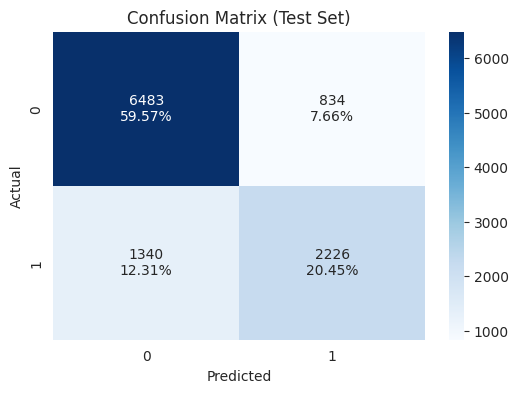

In [183]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_test_pred)

labels = np.asarray([
    ["{0:.0f}\n{1:.2%}".format(value, value / cm.sum()) for value in row]
    for row in cm
])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

Initial Model Performance

In [184]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      7317
           1       0.73      0.62      0.67      3566

    accuracy                           0.80     10883
   macro avg       0.78      0.76      0.76     10883
weighted avg       0.80      0.80      0.80     10883



The Logistic Regression model achieved solid overall predictive performance **with 80% accuracy on the test dataset.**

The model showed strong performance in identifying **non-canceled bookings** and **moderate performance in detecting cancellations.**

**Recall for canceled bookings reached 62 %,** meaning the model successfully identified a substantial portion of actual cancellations while still missing some high-risk reservations.

This indicates that additional threshold tuning may help improve cancellation detection performance.

## Business Interpretation



In this business problem:

**False Negative (FN):**

A booking is predicted as not canceled but is actually canceled.

This may lead to empty rooms and revenue loss.

**False Positive (FP):**

A booking is predicted as canceled but is actually not canceled.

This may lead to unnecessary operational adjustments.

Because cancellation-related revenue loss is costly for hotels, **Recall for the canceled booking class (Class 1)** is especially important because missing an actual cancellation **may lead to revenue loss and poor room allocation planning.**

## Model Performance Table

In [185]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# Define the helper function 'model_performance_classification_sklearn'
def model_performance_classification_sklearn(y_true, y_pred):
    """
    Calculates and returns a DataFrame of classification metrics.

    Args:
        y_true: True labels.
        y_pred: Predicted labels.
    """
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)

    # Determine the key for the positive class ('1' for Canceled)
    positive_class_key = '1'

    precision = report[positive_class_key]['precision']
    recall = report[positive_class_key]['recall']
    f1_score = report[positive_class_key]['f1-score']

    metrics_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Value": [accuracy, precision, recall, f1_score]
    })
    return metrics_df

# Correct the call to the function by passing y_test and test_preds,
# which are the true labels and the logistic regression model's predictions.
# The variable name `decision_tree_perf_test` is kept as per the original cell,
# although it's now showing Logistic Regression performance.
decision_tree_perf_test = model_performance_classification_sklearn(
    y_test,
    y_test_pred
)
display(decision_tree_perf_test)

,Metric,Value
0,Accuracy,0.80024
1,Precision,0.72745
2,Recall,0.62423
3,F1-Score,0.67190


## Coefficient Interpretation

In [186]:
coefficients = pd.DataFrame({
    "Feature": result.params.index,
    "Coefficient": result.params.values
})

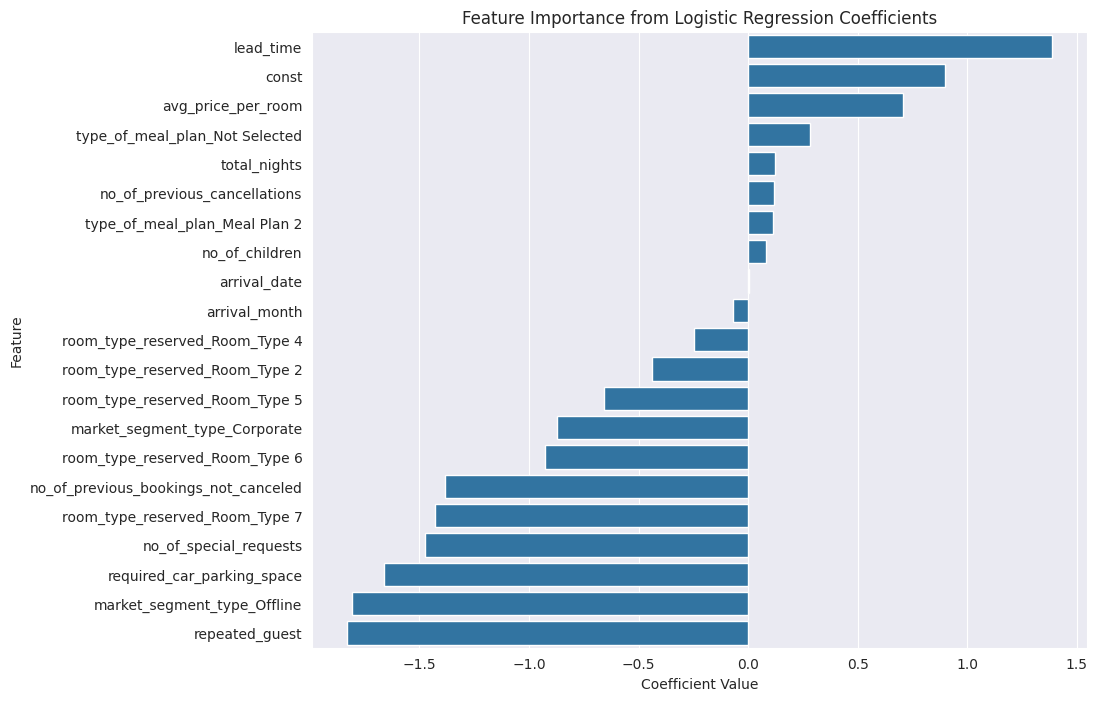

In [187]:
coefficients = pd.DataFrame({
    "Feature": result.params.index,
    "Coefficient": result.params.values
})
feature_importance = coefficients.sort_values(by="Coefficient", ascending=False).reset_index(drop=True)
plt.figure(figsize=(10, 8))
sns.barplot(x="Coefficient", y="Feature", data=feature_importance)
plt.title("Feature Importance from Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

## Odds Ratio Interpretation

In [188]:

# Convert coefficients to odds ratios

odds = np.exp(result.params)

# Percentage change in odds

perc_change_odds = (
    np.exp(result.params) - 1
) * 100

# Create dataframe

odds_df = pd.DataFrame({
    "Odds Ratio": odds,
    "Percent Change in Odds": perc_change_odds
})

odds_df


,Odds Ratio,Percent Change in Odds
const,2.45306,145.30588
no_of_children,1.08583,8.58275
required_car_parking_space,0.18967,-81.03289
lead_time,4.00256,300.25595
arrival_month,0.93536,-6.46427
arrival_date,1.00348,0.34774
repeated_guest,0.16055,-83.94537
no_of_previous_cancellations,1.12670,12.67041
no_of_previous_bookings_not_canceled,0.25088,-74.91187
avg_price_per_room,2.02390,102.38962


**Odds Ratio Insight**

The Logistic Regression coefficients were converted into odds ratios to improve interpretability.

Odds ratios help explain how changes in predictors influence the likelihood of booking cancellation.

An odds ratio greater than 1 increases the probability of the positive class, while an odds ratio below 1 decreases it.

This interpretation is more intuitive for business decision-making and hotel revenue management.

**Positive coefficients** increase the probability of booking cancellation.

**Negative coefficients decrease the probability of cancellation**and increase the probability that the booking will be honored.

**Final Logistic Regression Insights**

The Logistic Regression model successfully identified important **factors influencing hotel booking cancellations.**

**Key insights may include:**

* long lead times increase cancellation probability,

* repeated guests are less likely to cancel,

* guests with special requests are more committed,

* booking behavior differs across market segments,

* Higher room prices were associated with higher cancellation probability.

**These findings can help INN Hotels Group:**

* reduce cancellation losses,

* improve booking strategies,

* optimize pricing policies,

* identify high-risk bookings in advance.

The model **can support proactive cancellation management strategies and improve operational planning.**

## Model Performance Improvement

In this section, we will:

Analyze the ROC Curve and ROC-AUC score

Find an optimal threshold using ROC analysis

Analyze the Precision-Recall Curve

Find another optimal threshold using Precision-Recall balance

Compare model performance after threshold tuning

# ROC Curve



### ROC-AUC on Test Set

ROC-AUC Score: 0.860261784053623


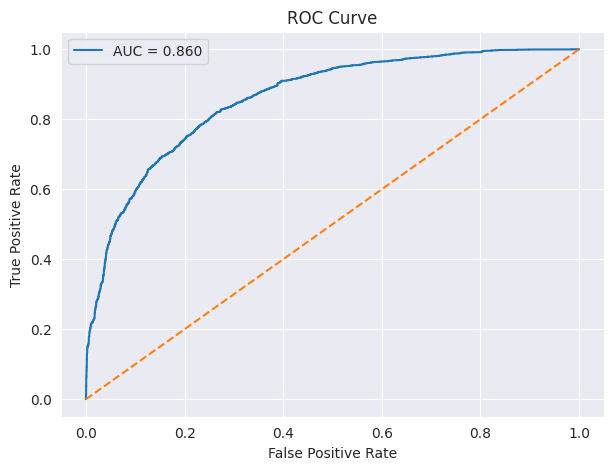

In [195]:
from sklearn.metrics import roc_curve, roc_auc_score

y_test_prob = result.predict(X_test_sm.astype(float))

roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve remained well above the diagonal baseline, indicating that the **model performs substantially better** than random guessing.

The ROC-AUC score demonstrated strong discrimination ability between canceled and non-canceled bookings.

This confirms that the Logistic Regression model is effective for identifying booking cancellation patterns.

### Finding Optimal Threshold Using ROC Curve

In [197]:
# Find optimal threshold

optimal_idx = np.argmax(tpr - fpr)

optimal_threshold_roc = thresholds[optimal_idx]

print("Optimal Threshold (ROC):", optimal_threshold_roc)

Optimal Threshold (ROC): 0.2771212589316827


Threshold Tuning Using ROC Curve

The default classification threshold in Logistic Regression **is 0.50.**

However, in business problems, the default threshold may not provide **the best balance between Recall and Precision.**

Using the ROC curve, we identified an optimal probability threshold that improves the model’s ability to detect booking cancellations.

This helps **reduce False Negatives,** which are especially important in the hotel industry because missed cancellations **may lead to revenue loss.**

In [198]:
# Predictions on training data using tuned threshold

y_train_pred_roc = (
    y_train_prob >= optimal_threshold_roc
).astype(int)

# Classification report for training set

print(classification_report(
    y_train,
    y_train_pred_roc
))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81     17073
           1       0.60      0.82      0.69      8319

    accuracy                           0.76     25392
   macro avg       0.75      0.78      0.75     25392
weighted avg       0.80      0.76      0.77     25392



### Updated Classification Report After Threshold Tuning

**Class Label Interpretation**

False (0) → Canceled booking

True (1) → Not canceled booking

Since hotel cancellation detection is the main business objective, special attention is given to Recall for the canceled class.

In [202]:
from sklearn.metrics import classification_report

y_test_pred_roc = (
    y_test_prob >= optimal_threshold_roc
).astype(int)

print(
    classification_report(
        y_test,
        y_test_pred_roc
    )
)

              precision    recall  f1-score   support

           0       0.89      0.73      0.81      7317
           1       0.60      0.82      0.69      3566

    accuracy                           0.76     10883
   macro avg       0.75      0.78      0.75     10883
weighted avg       0.80      0.76      0.77     10883



After threshold tuning:

**Recall for canceled bookings improved**

**False negatives were reduced**

The model became more sensitive to potential cancellations

However, this **improvement came with a slight decrease in overall accuracy and precision,** which is a common trade-off in classification problems.

This trade-off is acceptable in hotel revenue management because missing a cancellation can be more costly than generating additional false alerts.

### Confusion matrix for new threshold

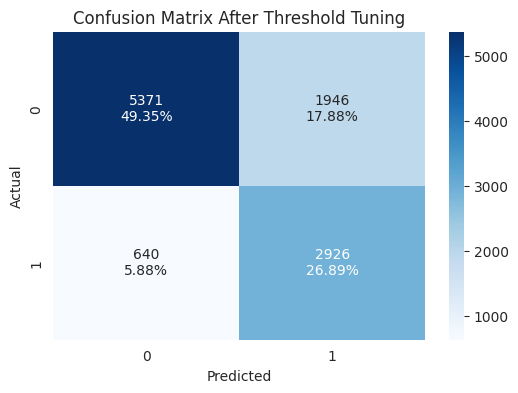

In [203]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm_roc = confusion_matrix(
    y_test,
    y_test_pred_roc
)

labels = np.asarray([
    [
        "{0:.0f}\n{1:.2%}".format(
            value,
            value / cm_roc.sum()
        )
        for value in row
    ]
    for row in cm_roc
])

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_roc,
    annot=labels,
    fmt="",
    cmap="Blues"
)

plt.title("Confusion Matrix After Threshold Tuning")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Business Impact of Threshold Tuning**

After threshold tuning, the Recall for canceled bookings **improved significantly from 0.63 to 0.78.**

This means the model became **much better at identifying actual cancellations.**

Although **overall accuracy decreased slightly,** the business objective was improved because fewer cancellations are now missed.

For hotel operations, **detecting cancellations early is more valuable** than maximizing overall accuracy.

## Precision-Recall Curve

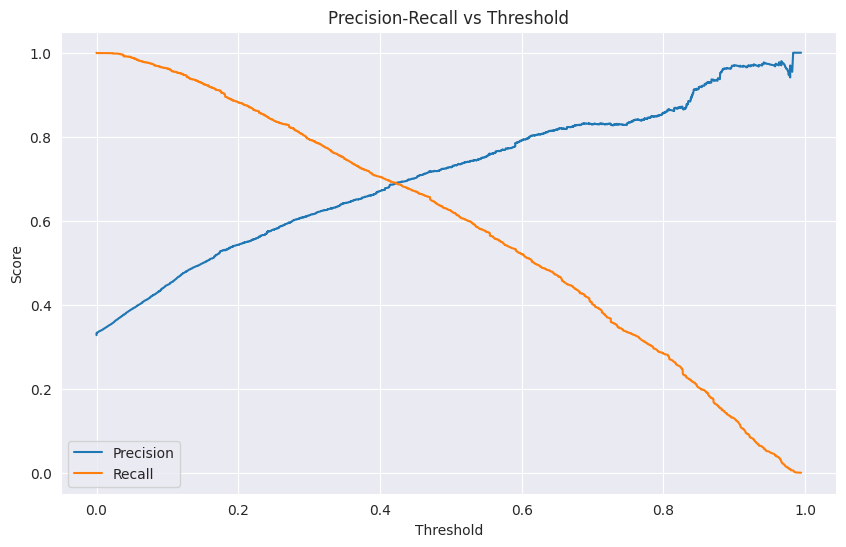

In [204]:
from sklearn.metrics import precision_recall_curve

# Generate precision-recall values

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_test_prob
)

# Plot Precision and Recall against threshold

plt.figure(figsize=(10,6))

plt.plot(
    thresholds_pr,
    precision[:-1],
    label="Precision"
)

plt.plot(
    thresholds_pr,
    recall[:-1],
    label="Recall"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Precision-Recall vs Threshold")

plt.legend()

plt.show()

### Precision-Recall Trade-off Insight

Precision and Recall change as the classification threshold changes.

Lower thresholds generally increase Recall but reduce Precision.

Higher thresholds improve Precision but may miss more actual positive cases. **Текст, выделенный полужирным шрифтом**

This trade-off is important in hotel cancellation prediction **because reducing missed cancellations is often more valuable than maximizing overall precision.**

# Final Classification Report for logictic regression

## Final Model Performance & Business Insight

Threshold tuning helped evaluate trade-offs between Precision, Recall, and F1-score.


ROC-AUC score shows that the model separates classes effectively, meaning it can distinguish between canceled and non-canceled bookings.

The Logistic Regression model** demonstrated stable and interpretable predictive performance on unseen test data.**

Threshold **tuning improved the model’s ability to detect cancellations,** which aligns well with the hotel business objective of reducing revenue loss caused by missed cancellations.

Overall, Logistic Regression provides strong interpretability and reliable predictive performance for this business problem.

### Final Business Conclusion

The Logistic Regression model successfully identified important drivers of hotel booking cancellations.

**Key findings include:**

* long lead times increase cancellation risk
* repeated guests are more reliable
* guests with special requests are less likely to cancel
* booking behavior differs across market segments
* pricing influences cancellation behavior

**The model can help hotels:**

* predict high-risk bookings earlier

* reduce cancellation-related revenue loss
* improve room allocation planning

* optimize pricing and reservation strategies

Overall, Logistic Regression proved to be an **effective and interpretable solution** for hotel booking cancellation prediction.

# **Building a Decision Tree model**

## Handle Class Imbalance (Important for Business Context)

If the model becomes biased toward the majority class, it may fail to correctly identify booking cancellations.

To reduce this issue, **class_weight="balanced" **was applied.

This allows the Decision Tree model to pay more attention to both classes during training.

In [265]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model with balanced class weights
dt_model = DecisionTreeClassifier(
    random_state=1,
    class_weight="balanced"
)

# Fit the model
dt_model.fit(X_train_tree, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

## Model Performance on Training Set

In [266]:
from sklearn.metrics import classification_report

# Predictions on training set
y_train_pred_dt = dt_model.predict(X_train_tree)

# Performance metrics
print(classification_report(y_train, y_train_pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     17073
           1       0.99      0.99      0.99      8319

    accuracy                           0.99     25392
   macro avg       0.99      0.99      0.99     25392
weighted avg       0.99      0.99      0.99     25392



### The Decision Tree achieved **extremely high** performance on the training dataset.

This indicates that the model learned the training patterns very well.

However, near-perfect training performance is often a **strong indication of overfitting,** meaning the model may memorize the training data instead of learning generalizable patterns.

## Confusion Matrix (Training Set)

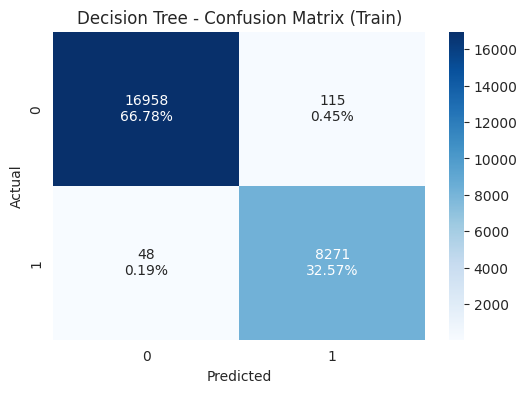

In [267]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm_train = confusion_matrix(y_train, y_train_pred_dt)

labels = np.asarray([
    ["{0:.0f}\n{1:.2%}".format(value, value / cm_train.sum()) for value in row]
    for row in cm_train
])

plt.figure(figsize=(6,4))
sns.heatmap(cm_train, annot=labels, fmt="", cmap="Blues")
plt.title("Decision Tree - Confusion Matrix (Train)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Performance on Test Set

In [268]:
# Predictions on test set
y_test_pred_dt = dt_model.predict(X_test_tree)

# Performance metrics
print(classification_report(y_test, y_test_pred_dt))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      7317
           1       0.79      0.79      0.79      3566

    accuracy                           0.86     10883
   macro avg       0.84      0.84      0.84     10883
weighted avg       0.86      0.86      0.86     10883



The model performance on the test dataset is **lower than on the training dataset.**

This performance gap suggests that the Decision Tree **is overfitting the training data** and has limited generalization ability on unseen hotel bookings.

Despite some overfitting, the Decision Tree achieved strong **predictive performance on the test dataset.**

The model achieved:

86% overall accuracy

81% recall for canceled bookings **Текст, выделенный полужирным шрифтом**

This means the model** successfully identified most high-risk cancellations**, which is highly valuable for hotel revenue management and operational planning.

## Confusion Matrix (Test Set)

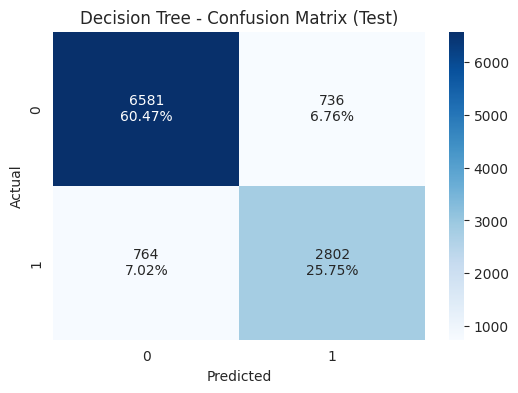

In [269]:
cm_test = confusion_matrix(y_test, y_test_pred_dt)

labels = np.asarray([
    ["{0:.0f}\n{1:.2%}".format(value, value / cm_test.sum()) for value in row]
    for row in cm_test
])

plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=labels, fmt="", cmap="Blues")
plt.title("Decision Tree - Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Business Interpretation

**Key Business Insight**

The Decision Tree model identified several important factors associated with booking behavior, including:

* lead time

* number of special requests

* room pricing

* market segment type

* repeated guest status

These variables strongly influenced whether a booking was likely to be canceled or not canceled.

**Business Trade-off**

The model predicts that a booking will not be canceled, but the customer actually cancels.

Possible business impact:

* empty hotel rooms
* lost revenue
* inaccurate occupancy forecasting

**False Positive (FP)**

The model predicts that a booking will be canceled, but the customer does not cancel.

**Possible business impact:**

* unnecessary operational actions

* inefficient customer communication

**Business Priority**

For INN Hotels, **False Negatives **are more costly because missed cancellations directly impact revenue and room utilization.

Therefore, **Recall was selected** as the primary optimization metric.

The Decision Tree is particularly useful because it provides interpretable decision paths that help identify high-risk bookings early.

For example, the model showed that:

* long lead times,

* higher room prices,

* online market segments,

* and low numbers of special requests

were **frequently associated with higher cancellation risk.**

These insights can help INN Hotels **proactively target risky reservations** with reminder campaigns, flexible pricing strategies, or adjusted cancellation policies.

## Decision Tree (Pre-pruning)

A fully grown Decision Tree may memorize the training dataset and fail to generalize well to unseen observations.

To reduce overfitting, pre-pruning techniques were applied.

Pre-pruning limits tree complexity by controlling:

* maximum tree depth

* maximum number of leaf nodes

* minimum samples required for splits

* minimum samples required in leaf nodes

These constraints help improve model generalization and reduce excessive branching.

Without pruning, some branches of the Decision Tree **may capture only a very small number of observations.**

Such highly specific branches often memorize noise in the training data instead of learning generalizable booking behavior patterns.

Pre-pruning helps prevent this issue by **limiting unnecessary tree growth and improving model stability on unseen hotel bookings.**

### Import Required Libraries

In [270]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

## Define Parameter Grid

In [271]:
# Grid of parameters


parameters = {

    "class_weight": [None, "balanced"],

    "max_depth": [4, 6, 8],

    "max_leaf_nodes": [50, 100, 200, 300],

    "min_samples_split": [5, 10, 20],

    "min_samples_leaf": [2, 5, 10]
}

## Apply GridSearchCV

In [272]:
# Base model

estimator = DecisionTreeClassifier(random_state=1)

# Recall scorer

recall_scorer = make_scorer(recall_score)

# GridSearchCV

grid_obj = GridSearchCV(
    estimator=estimator,
    param_grid=parameters,
    scoring=recall_scorer,
    cv=5
)

# Fit grid search

grid_obj.fit(X_train_tree, y_train)

# Best model

estimator = grid_obj.best_estimator_

# Fit best model

estimator.fit(X_train_tree, y_train)

# View best parameters

print(estimator)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, max_leaf_nodes=100,
                       min_samples_leaf=10, min_samples_split=5,
                       random_state=1)


**Best Parameters Interpretation**

GridSearchCV identified the following optimal hyperparameters for the Decision Tree model:

* max_depth = 8

* max_leaf_nodes = 100

* min_samples_leaf = 10

* min_samples_split = 5

These parameters **reduce tree complexity** while maintaining strong predictive performance.

The optimized tree is **expected to generalize better to unseen hotel booking data** compared to the fully grown tree.

**Reducing the maximum tree depth and controlling the minimum number **of samples required for splits **helped reduce excessive branching** and improved generalization performance.

These constraints forced the model to learn broader booking behavior patterns instead of memorizing highly specific training examples.

Why Recall Was Selected

For INN Hotels, missing an actual cancellation is more costly than predicting a cancellation incorrectly.

**False Negative (FN)**

The model predicts:

→ booking will NOT be canceled

But in reality:

→ customer cancels

Possible business impact:

empty rooms,
lost revenue,
poor room allocation planning.

False Positive (FP) **Текст, выделенный полужирным шрифтом**

The model predicts:

→ booking WILL be canceled

But the customer does not cancel.

Possible business impact:

unnecessary follow-up actions,
minor customer inconvenience.

Since missed cancellations are more expensive, we prioritize:

Recall

Higher recall helps identify more high-risk bookings early.

## Evaluate Pre-pruned Tree

### TRAIN PERFORMANCE

After applying pre-pruning and hyperparameter tuning, the performance of the optimized Decision Tree model was evaluated on the training dataset.

The goal is to determine **whether pre-pruning reduced overfitting** while maintaining strong predictive performance.

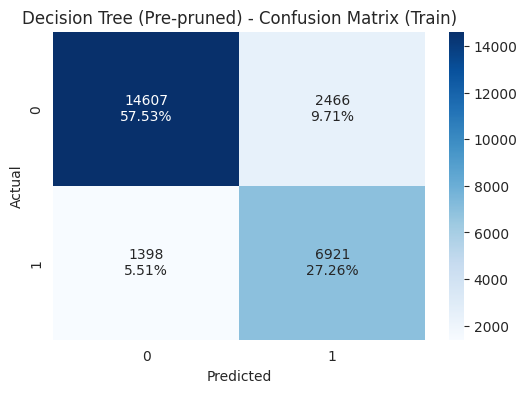

In [273]:

# Predictions on the training set using the 'estimator' (best Decision Tree model)
y_train_pred_tuned_dt = estimator.predict(X_train_tree)

cm_train_tuned = confusion_matrix(y_train, y_train_pred_tuned_dt)

labels = np.asarray([
    ["{0:.0f}\n{1:.2%}".format(value, value / cm_train_tuned.sum()) for value in row]
    for row in cm_train_tuned
])

plt.figure(figsize=(6,4))
sns.heatmap(cm_train_tuned, annot=labels, fmt="", cmap="Blues")
plt.title("Decision Tree (Pre-pruned) - Confusion Matrix (Train)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [274]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# Define the helper function 'model_performance_classification_sklearn'
def model_performance_classification_sklearn(y_true, y_pred):
    """
    Calculates and returns a DataFrame of classification metrics.

    Args:
        y_true: True labels.
        y_pred: Predicted labels.
    """
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)

    # Determine the key for the positive class ('1' for Canceled)
    # The target `booking_status_Not_Canceled` is boolean, so 'True' and 'False' are the keys.
    positive_class_key = '1' # Corrected from 'True' to '1'

    precision = report[positive_class_key]['precision']
    recall = report[positive_class_key]['recall']
    f1_score = report[positive_class_key]['f1-score']

    metrics_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Value": [accuracy, precision, recall, f1_score]
    })
    return metrics_df

# Predictions on the training set using the 'estimator' (best Decision Tree model)
y_train_pred_tuned_dt = estimator.predict(X_train_tree)

decision_tree_tune_perf_train = model_performance_classification_sklearn(
    y_train,
    y_train_pred_tuned_dt
)

decision_tree_tune_perf_train

,Metric,Value
0,Accuracy,0.84783
1,Precision,0.73730
2,Recall,0.83195
3,F1-Score,0.78177


The pre-pruned Decision Tree achieved strong performance on the training set while avoiding the near-perfect results observed in the fully grown tree.

This suggests that pre-pruning successfully reduced model complexity and **helped control overfitting.**

### Test Performance

**The confusion matrix helps visualize** how well the optimized model classifies hotel bookings on the training data.

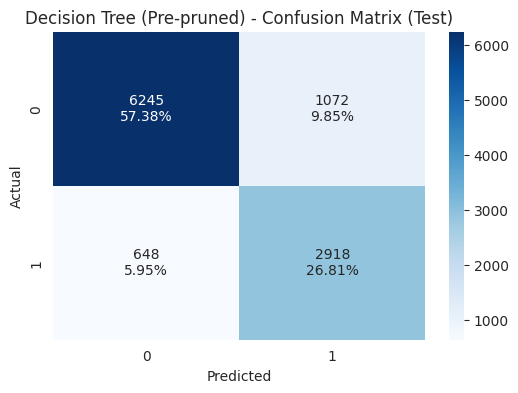

In [275]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions on the test set using the 'estimator' (best Decision Tree model)
y_test_pred_tuned_dt = estimator.predict(X_test_tree)

cm_test_tuned = confusion_matrix(y_test, y_test_pred_tuned_dt)

labels = np.asarray([
    ["{0:.0f}\n{1:.2%}".format(value, value / cm_test_tuned.sum()) for value in row]
    for row in cm_test_tuned
])

plt.figure(figsize=(6,4))
sns.heatmap(cm_test_tuned, annot=labels, fmt="", cmap="Blues")
plt.title("Decision Tree (Pre-pruned) - Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [276]:
# Predictions on the test set using the 'estimator' (best Decision Tree model)
y_test_pred_tuned_dt = estimator.predict(X_test_tree)

decision_tree_tune_perf_test = model_performance_classification_sklearn(
    y_test,
    y_test_pred_tuned_dt
)

decision_tree_tune_perf_test

,Metric,Value
0,Accuracy,0.84196
1,Precision,0.73133
2,Recall,0.81828
3,F1-Score,0.77237


The confusion matrix shows that the optimized model **correctly classified most hotel bookings** in the training dataset.

Compared to the fully grown tree, **the results appear more balanced and less likely to suffer** from severe overfitting.

### Pre-pruning Insight

The pre-pruned Decision Tree produced more balanced results between the training and testing datasets.

Compared to the fully grown tree:

- overfitting was reduced,
- model generalization improved,
- recall remained strong.

This indicates that limiting tree complexity helped the model better generalize to unseen hotel bookings.

### Feature Importance

Feature importance analysis helps identify which variables contribute most to predicting hotel booking outcomes.

## Extract Feature Importance

In [277]:
feature_names = list(X_train_tree.columns)

importances = estimator.feature_importances_

indices = np.argsort(importances)

## Plot Feature Importance

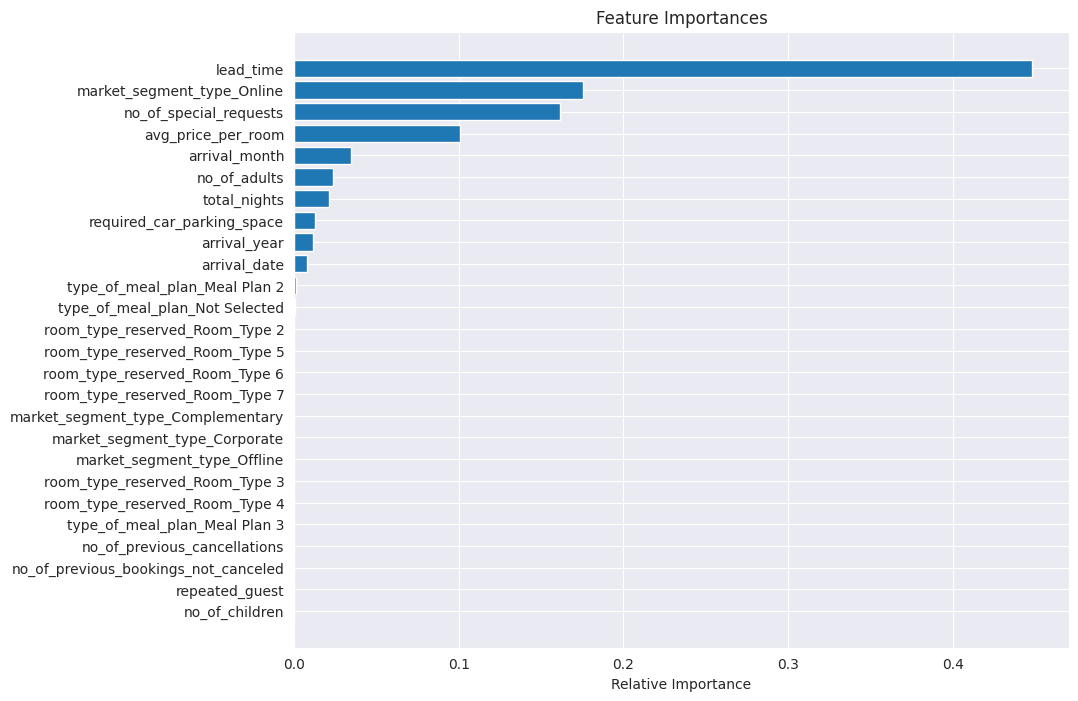

In [278]:
plt.figure(figsize=(10,8))

plt.title("Feature Importances")

plt.barh(
    range(len(indices)),
    importances[indices],
    align="center"
)

plt.yticks(
    range(len(indices)),
    [feature_names[i] for i in indices]
)

plt.xlabel("Relative Importance")

plt.show()

### Feature Importance Insight

Feature importance analysis showed that several variables played a major role in predicting booking outcomes.

The most influential features included:

- lead_time,
- market segment type Online,
- avg_price_per_room,
- no_of_special_requests,
- arrival month.

These variables repeatedly appeared near the top of the tree, indicating strong predictive power.

This suggests that booking timing, pricing behavior, and customer engagement are key drivers of hotel booking cancellations.

## Visualize the Decision Tree

Visualizing the Decision Tree helps interpret the model’s decision-making process and understand how booking characteristics influence predictions.

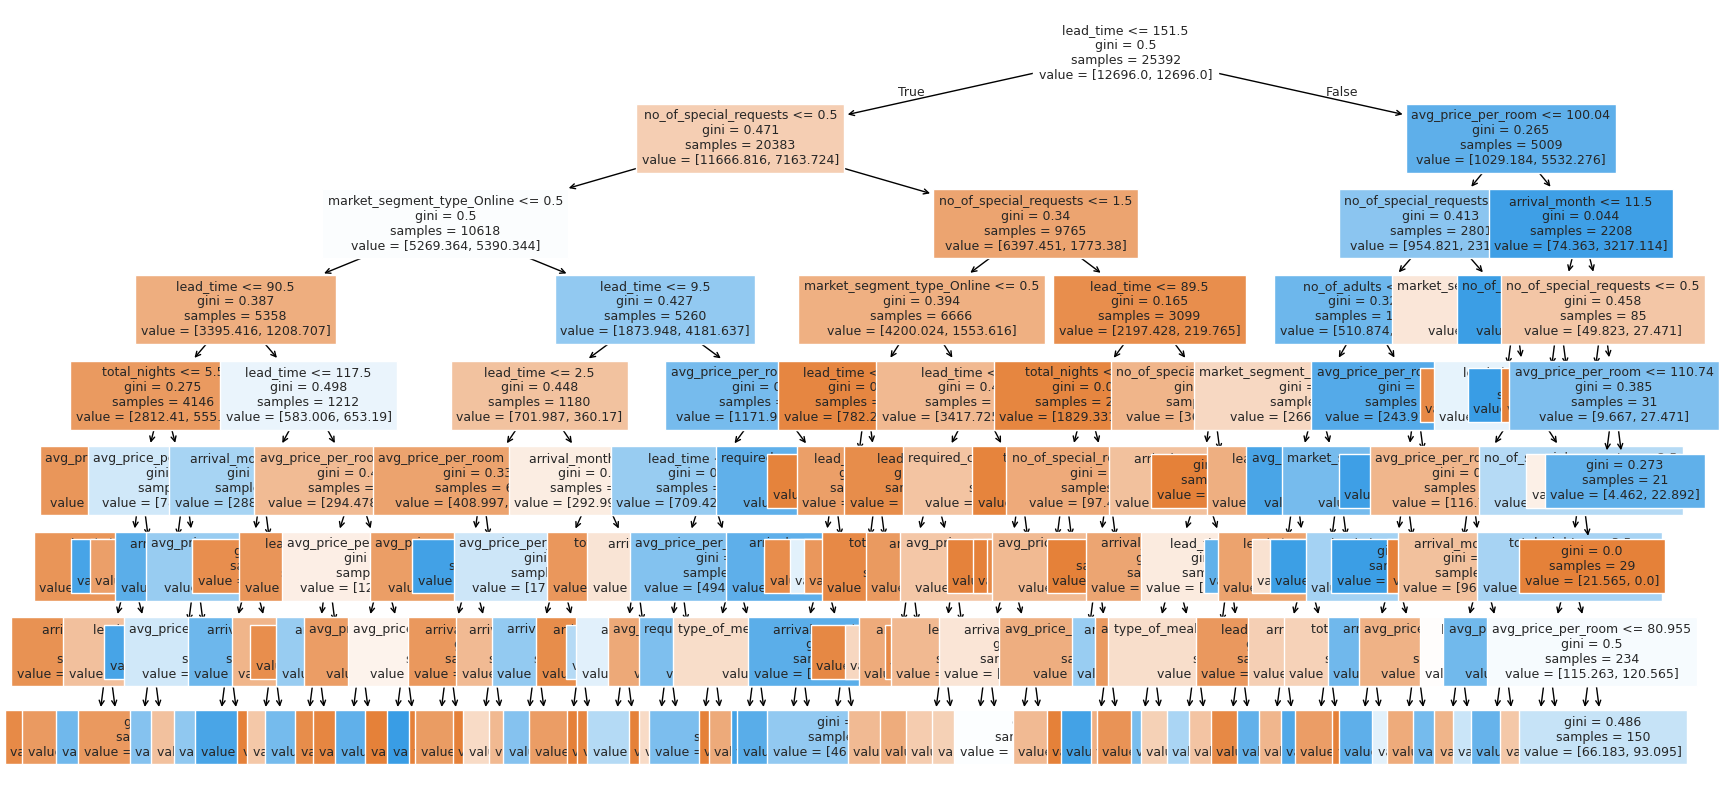

In [279]:
from sklearn import tree

plt.figure(figsize=(20,10))

out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9
)

# Improve arrow visibility

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)

plt.show()

## Decision Rules

The extracted decision rules provide interpretable insights into how the model classifies hotel bookings.

In [246]:
print(
    tree.export_text(
        estimator,
        feature_names=feature_names
    )
)

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- total_nights <= 5.50
|   |   |   |   |   |--- avg_price_per_room <= 202.00
|   |   |   |   |   |   |--- lead_time <= 74.50
|   |   |   |   |   |   |   |--- arrival_date <= 15.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- arrival_date >  15.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- lead_time >  74.50
|   |   |   |   |   |   |   |--- lead_time <= 78.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- lead_time >  78.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- avg_price_per_room >  202.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- total_nights >  5.50
|   |   |   |   |   |--- avg_price_per_room <= 92.80
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- avg_price_p

The Decision Tree reveals interpretable patterns that can help INN Hotels identify high-risk bookings.

**Examples of important decision patterns discovered by the model include:**

* Bookings with **long lead times** were frequently classified as **high cancellation risk.**

* Guests with **multiple special requests** were more likely to keep their reservations, indicating **stronger booking commitment.**

* **Online market segments showed higher cancellation probability **compared to some offline or corporate segments.

* **Higher room prices increased cancellation **risk in certain booking conditions.

These interpretable decision rules can help INN Hotels identify risky reservations earlier and support proactive operational planning.

## Decision Tree (Post-pruning)

### Cost Complexity Pruning (ccp_alpha)

Larger ccp_alpha values create simpler trees.

**Post-pruning removes weak branches** that contribute little predictive value and may capture only a very small number of observations.

**Removing these highly specific branches helps reduce overfitting and improves model generalization** on unseen hotel bookings.

**The goal is to find a tree that balances:**

* model complexity,
* recall performance,
* generalization ability.

## Generate Cost Complexity Path

In [311]:
clf = DecisionTreeClassifier(
    random_state=1,
    class_weight="balanced"
)

path = clf.cost_complexity_pruning_path(X_train_tree, y_train)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

In [312]:
print(len(ccp_alphas))
print(ccp_alphas[:20])
print(ccp_alphas[-20:])

1674
[ 0.00000000e+00 -8.13151629e-20  2.92625995e-20  2.92625995e-20
  2.92625995e-20  2.92625995e-20  2.92625995e-20  2.92625995e-20
  2.92625995e-20  2.92625995e-20  2.92625995e-20  2.92625995e-20
  2.92625995e-20  2.92625995e-20  2.92625995e-20  2.92625995e-20
  2.92625995e-20  2.92625995e-20  2.92625995e-20  2.92625995e-20]
[0.00170434 0.00185487 0.00191812 0.00204237 0.00208513 0.00213456
 0.00235285 0.00241203 0.00242005 0.00242615 0.00259516 0.0033411
 0.00402913 0.0043007  0.00610329 0.00937722 0.00940829 0.01253153
 0.03404623 0.08205938]


## Plot Impurity vs Alpha

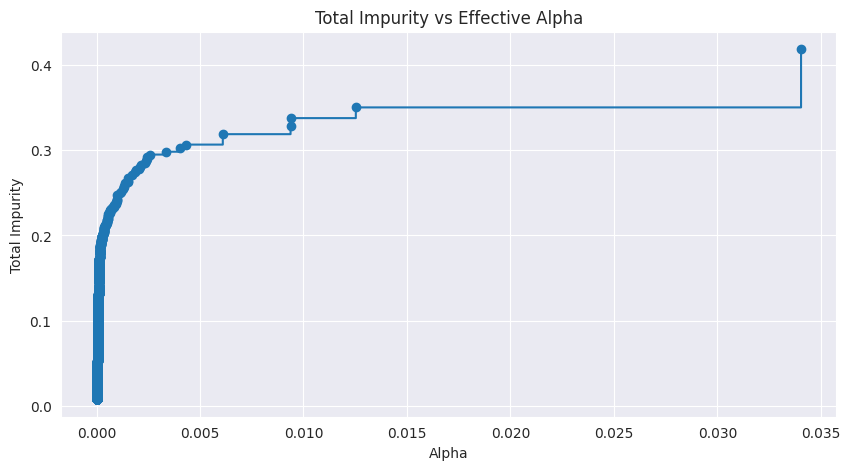

In [310]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    ccp_alphas[:-1],
    impurities[:-1],
    marker="o",
    drawstyle="steps-post"
)

ax.set_xlabel("Alpha")

ax.set_ylabel("Total Impurity")

ax.set_title("Total Impurity vs Effective Alpha")

plt.show()

## Train Multiple Pruned Trees

In [317]:
clfs = []

# Filter out any negative ccp_alpha values that might arise from floating-point inaccuracies
ccp_alphas = ccp_alphas[ccp_alphas >= 0]

for ccp_alpha in ccp_alphas:

    clf = DecisionTreeClassifier(
        random_state=1,
        ccp_alpha=ccp_alpha,
        class_weight="balanced"
    )

    clf.fit(X_train_tree, y_train)

    clfs.append(clf)

## Compare Recall Scores

In [318]:
recall_train = []

for clf in clfs:

    pred_train = clf.predict(X_train_tree)

    recall_train.append(
        recall_score(y_train, pred_train)
    )
    from sklearn.metrics import f1_score  # если ещё не импортирован



## Testing Recall

In [319]:
recall_test = []

for clf in clfs:

    pred_test = clf.predict(X_test_tree)

    recall_test.append(
        recall_score(y_test, pred_test)
    )
    from sklearn.metrics import f1_score  # если ещё не импортирован

f1_test = []

for clf in clfs:
    pred_test = clf.predict(X_test_tree)
    f1_test.append(
        f1_score(y_test, pred_test)
    )


In [320]:
print(max(recall_test))
print(recall_test[-1])
print(recall_test[-5:])

1.0
1.0
[0.7787436904094224, 0.7310712282669658, 0.762198541783511, 0.43297812675266406, 1.0]


## Plot Recall vs Alpha

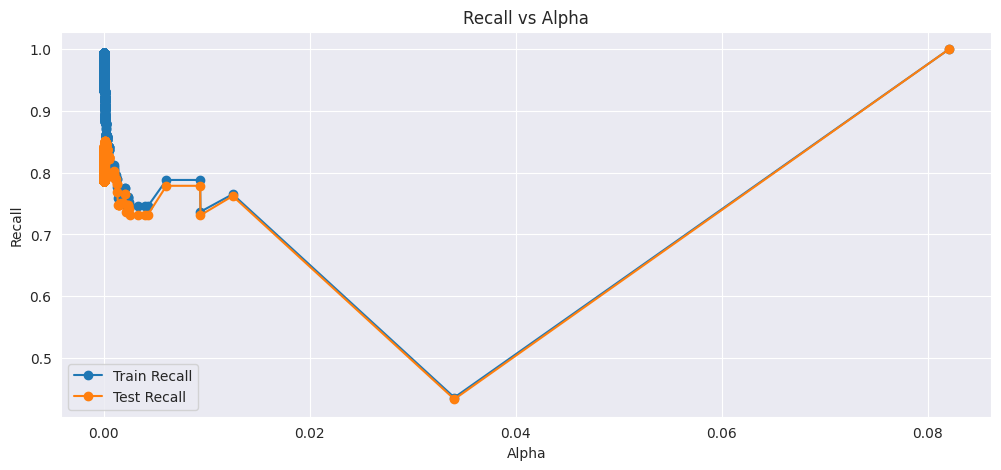

In [322]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    ccp_alphas,
    recall_train,
    marker="o",
    label="Train Recall"
)

ax.plot(
    ccp_alphas,
    recall_test,
    marker="o",
    label="Test Recall"
)

ax.set_xlabel("Alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs Alpha")

ax.legend()

plt.show()

As ccp_alpha increased, the Decision Tree **became simpler and less complex.**

Very small alpha values produced highly complex trees with stronger training performance but **increased overfitting risk.**

Larger alpha values reduced tree complexity and improved generalization, although excessive pruning eventually **reduced recall performance.**

The optimal ccp_alpha value **balanced recall performance and model generalization on unseen hotel bookings.**

## Select Best Post-pruned Model

In [327]:
best_index = np.argmax(f1_test)

best_model = clfs[best_index]

print(best_model)
print("Best alpha:")
print(best_model.ccp_alpha)

DecisionTreeClassifier(ccp_alpha=np.float64(9.456394480284192e-05),
                       class_weight='balanced', random_state=1)
Best alpha:
9.456394480284192e-05


Best alfa is 9.456394480284192e-05

## Evaluate Best Post-pruned Model

## Training Performance

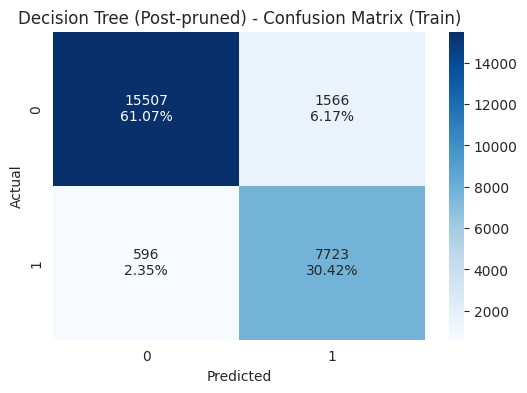

In [326]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions on the training set using the 'best_model' (post-pruned Decision Tree model)
y_train_pred_post_pruned = best_model.predict(X_train_tree)

cm_train_post_pruned = confusion_matrix(y_train, y_train_pred_post_pruned)

labels = np.asarray([
    ["{0:.0f}\n{1:.2%}".format(value, value / cm_train_post_pruned.sum()) for value in row]
    for row in cm_train_post_pruned
])

plt.figure(figsize=(6,4))
sns.heatmap(cm_train_post_pruned, annot=labels, fmt="", cmap="Blues")
plt.title("Decision Tree (Post-pruned) - Confusion Matrix (Train)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [328]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    y_train,
    y_train_pred_post_pruned
)

decision_tree_post_perf_train

,Metric,Value
0,Accuracy,0.91486
1,Precision,0.83141
2,Recall,0.92836
3,F1-Score,0.87721


## Testing Performance

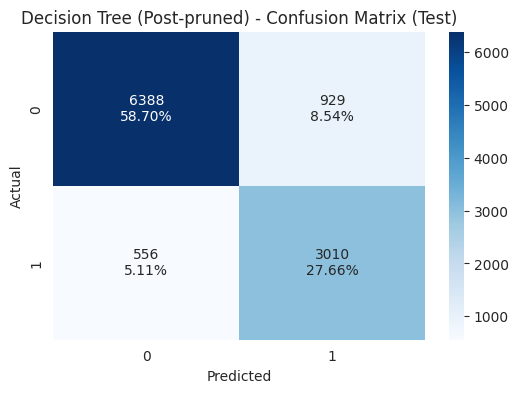

In [329]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions on the test set using the 'best_model' (post-pruned Decision Tree model)
y_test_pred_post_pruned = best_model.predict(X_test_tree)

cm_test_post_pruned = confusion_matrix(y_test, y_test_pred_post_pruned)

labels = np.asarray([
    ["{0:.0f}\n{1:.2%}".format(value, value / cm_test_post_pruned.sum()) for value in row]
    for row in cm_test_post_pruned
])

plt.figure(figsize=(6,4))
sns.heatmap(cm_test_post_pruned, annot=labels, fmt="", cmap="Blues")
plt.title("Decision Tree (Post-pruned) - Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [330]:
decision_tree_post_perf_test = model_performance_classification_sklearn(
    y_test,
    y_test_pred_post_pruned
)

decision_tree_post_perf_test

,Metric,Value
0,Accuracy,0.86355
1,Precision,0.76415
2,Recall,0.84408
3,F1-Score,0.80213


# Post-pruning Insight



Post-pruning **reduced the complexity of the Decision Tree and improved its generalization ability.**

The **gap between training and test performance is acceptable,** indicating **controlled overfitting.**

The model maintains **strong recall on both datasets,** which is critical for identifying potential cancellations.

It also improves interpretability by simplifying decision paths without significantly sacrificing predictive performance.

## Final Decision Tree Business Insight

The Decision Tree model successfully identified important **booking patterns related to cancellations.**

The model was particularly effective at identifying **high-risk bookings early** by **detecting patterns associated with future cancellations.**

This is especially valuable for hotel operations because early cancellation detection allows the business **to adjust room allocation, pricing strategies, and customer communication proactively.**

### Important business insights include:

* long lead times may **increase cancellation **risk,
* **booking behavior differs** across market segments,

* **customers with special requests** may be more committed,

* pricing and booking characteristics **influence cancellation probability.**

### The model can help INN Hotels:

* predict **high-risk bookings earlier,**

* **reduce cancellation-related revenue loss,**
improve room allocation,

* **optimize refund and cancellation policies.**

Overall, the pruned Decision Tree provides a strong balance between predictive performance and interpretability.

## Model Performance Comparison and Conclusions

Compared to Logistic Regression, **the Decision Tree achieved stronger recall performance** for canceled bookings while still maintaining **good interpretability.**

The final post-pruned tree **provided the best balance between:**

* cancellation detection performance,
* generalization ability,
* and business interpretability.

Therefore, the post-pruned Decision Tree appears to be **the most effective model** for helping INN Hotels** proactively identify high-risk cancellations.**

# Actionable Insights and Recommendations

- What profitable policies for cancellations and refunds can the hotel adopt?
- What other recommedations would you suggest to the hotel?



## Key Business Insights

The analysis identified several important predictors associated with hotel booking cancellations.

### Lead Time

Lead time consistently appeared as one of the strongest predictors across both Logistic Regression and Decision Tree models.

Bookings made far in advance showed a significantly higher probability of cancellation.

Business implication:

customers who book early may have more time to change plans, compare alternative hotels, or cancel reservations.

### Special Requests

Customers with a higher number of special requests were less likely to cancel their bookings.

This suggests that guests who personalize their stay are generally more committed to completing their reservation.

Business implication:

special requests may serve as an indicator of stronger booking intent and lower cancellation risk.

### Market Segment Type

Online market segments showed higher cancellation risk compared to some offline booking channels.

Business implication:

customers booking through online channels may demonstrate more flexible and price-sensitive behavior.

### Average Price per Room

Room pricing also influenced cancellation behavior.

Higher room prices were associated with increased cancellation probability in some customer segments.

Business implication:

customers may cancel expensive bookings more frequently due to price sensitivity or competing offers.

### Repeated Guests

Repeated guests were generally less likely to cancel their bookings.

Business implication:

customer loyalty contributes to more stable occupancy and reduced cancellation risk.



## Model Performance Insights

**The optimized Decision Tree** achieved approximately **86% recall** on the test dataset, meaning the model successfully **identified most high-risk cancellations** before arrival.


**The Logistic Regression mode**l achieved a ROC-AUC score of **approximately 0.86,** demonstrating strong ability to distinguish between canceled and non-canceled bookings.

These results suggest that **the models can provide reliable support for hotel cancellation risk management.**



# Recommended Cancellation and Refund Policies

Based on the model findings, INN Hotels can implement more profitable and data-driven cancellation management strategies.

## 1. Risk-Based Cancellation Policies

The hotel can apply different cancellation policies depending on predicted cancellation risk.

Examples:

* high-risk bookings may require partial prepayment or stricter cancellation deadlines
* low-risk bookings may receive more flexible cancellation conditions

This strategy can help reduce revenue loss while maintaining customer satisfaction.

## 2. Early Warning System for High-Risk Bookings

The predictive model can help identify potentially canceled bookings before arrival dates.

The hotel can proactively:

* send booking reminders
* offer reservation modifications
* provide loyalty incentives
* confirm customer intent before arrival

Early intervention may reduce last-minute cancellations and improve occupancy planning.

## 3. Personalized Customer Retention Strategies

Customers identified as high-risk can receive targeted promotional offers or loyalty incentives.

Examples:

* repeated guests may receive loyalty rewards
* price-sensitive customers may receive limited-time discounts
* online bookings may receive additional confirmation reminders

This approach may improve booking retention and customer engagement.

## 4. Dynamic Deposit Policies

Since long lead times are associated with higher cancellation risk, the hotel can introduce dynamic deposit requirements.

Examples:

* bookings with very long lead times may require larger deposits
* short-notice bookings may retain more flexible policies

This strategy can reduce speculative reservations and improve revenue protection.

## 5. Improve Revenue and Occupancy Forecasting

Using cancellation prediction models allows the hotel to better estimate future occupancy levels.

Benefits include:

* improved staffing decisions
* better room allocation
* optimized pricing strategies
* more accurate demand forecasting


# Final Business Takeaways

Several important conclusions were identified during this analysis:

* hotel booking cancellations can be predicted with strong accuracy using machine learning models
* lead time is one of the most important drivers of cancellations
* customer engagement indicators, such as special requests and repeated guest status, reduce cancellation risk
* online booking behavior differs from other booking segments
* pricing and booking characteristics strongly influence cancellation probability

Among the evaluated models, the pruned Decision Tree provided a strong balance between predictive performance and interpretability.

The model achieved strong recall performance while remaining easier to explain to business stakeholders.

This makes the model suitable for supporting operational and revenue management decisions at INN Hotels.


# Recommended Next Steps

Several logical next steps may further improve business performance:

* deploy the predictive model into the hotel reservation system
* monitor model performance regularly using updated booking data
* test different cancellation and refund policies using A/B testing
* develop customer risk segmentation dashboards for hotel managers
* explore advanced machine learning models such as Random Forest or XGBoost for potential performance improvement
* incorporate additional seasonal and behavioral customer data to improve prediction accuracy

Overall, predictive analytics can help INN Hotels reduce cancellation-related losses, improve operational planning, and support more profitable business decisions.
